# Early Completion Risk Modeling: Progress-Aware Prediction and Engagement-Only Robustness Check

> **Reproducibility Note**
>
> This project includes a `renv.lock` file that records the R package versions used during development and validation.
>
> To reproduce the project environment, open the project root directory and run:
>
> ```r
> install.packages("renv")
> renv::restore()
> ```
>
> The project was developed and tested with R 4.6.0 and `xgboost` 3.2.1.1. The exact package environment is recorded in `renv.lock`.

## Project Overview

### Objective

This project represents **Part 3** of the analytical workflow for the interactive **Data Analysis in R Course** on **Stepik**.

The objective is to build a supervised machine learning workflow that estimates a learner's likelihood of eventual course completion from behavior observed during the first **10 days** of activity.

[**Part 1: Product Analysis, Activation Gap Diagnosis, and Modeling Base Preparation**](01_product_analysis_activation_gap.ipynb) identified an early **Activation Gap**: many users disengage before moving from passive content consumption to meaningful practical activity. [**Part 2: Behavioral Segmentation and Completion Outcome Analysis**](02_behavioral_segmentation.ipynb) grouped resolved learners into three interpretable segments: **Passive Users**, **Steady Learners**, and **Burst Learners**.

Building on these findings, Part 3 moves from descriptive analysis to predictive modeling. The model estimates:

`P(Completed)`

For retention prioritization, this probability is converted into:

`Risk_Not_Completed = 1 - P(Completed)`

The resulting score is used primarily as a **ranking and prioritization signal**. Learners with lower predicted completion probability receive higher intervention priority.

---

### Project Context

The analytical workflow consists of three connected stages.

#### Part 1: Product Analysis and Modeling Base Preparation

The first phase analyzed raw Stepik event and submission logs to identify where users disengage. The largest observed loss occurred before the first meaningful practical action, especially before users started or submitted assignments. This pattern was summarized as the **Activation Gap**.

Part 1 also prepared the downstream analytical sample by applying P99-based filtering and excluding users whose trajectories were still considered unresolved under the 14-day inactivity rule.

#### Part 2: Behavioral Segmentation

The second phase used K-means clustering on the resolved `model_base` sample. The final segmentation used $K = 3$ and produced three business-actionable groups:

- **Passive Users** — minimal engagement and almost no practical progress;
- **Steady Learners** — sustained participation with moderate practical activity;
- **Burst Learners** — concentrated high-intensity activity and higher productivity per active day.

Completion outcomes were analyzed after clustering. More engaged segments showed higher completion shares, although `Not_Completed` remained the dominant outcome in all groups.

#### Part 3: Supervised Completion Risk Modeling

This phase uses first-10-day behavioral signals to estimate completion likelihood and rank learners by non-completion risk.

Cluster labels from Part 2 are used only for exploratory business interpretation. They are not included as supervised-model inputs, so the prediction workflow remains focused on directly observed early behavior.

---

### Data Description

The workflow uses two preprocessed user-level datasets derived from Stepik event and submission logs.

Both datasets are based on the resolved `model_base` sample created in Part 1. This sample excludes:

- P99-defined extreme high-activity users;
- users still classified as unresolved `is_in_progress` at the data snapshot under the 14-day inactivity rule.

#### 1. `prediction_features_10d_model_base.csv`

This dataset contains learner-level features calculated from the first 10 days of activity.

**Granularity**

- **1 row = 1 user**
- **Total users:** 18,168

Main feature groups include:

**General engagement, recency, and practical-start behavior**

- `n_viewed_all`
- `n_started_practical`
- `active_days`
- `days_since_last_action`

**Progress-aware, submission, score, and productivity-related behavior**

- `n_passed_all`
- `n_passed_practical`
- `n_submissions`
- `submission_correct_rate`
- `score_per_active_day`
- `steps_per_active_day`

The primary progress-aware setting uses both general engagement and progress-related features. The leakage-reduced robustness setting excludes direct pass-, score-, submission-related-, and progress-proxy variables.

#### 2. `completion_target_model_base.csv`

This dataset contains the final binary target:

- `Completed`
- `Not_Completed`

The two datasets are merged by `user_id`. Integrity checks verify one row per learner, no duplicate users, no missing targets, and no row loss during the merge.

---

### Prediction Target

Course completion follows the platform grading rule:

- **Completed** — at least **75 points**;
- **Not_Completed** — fewer than **75 points**.

The course has a maximum possible score of **88 points**, with **85+ points** corresponding to honor-level performance. This project models completion as a binary outcome and does not distinguish standard from honor completion.

Because completion is score-based, predictors describing passed steps, submissions, success rates, and early score accumulation may act as target proxies. They remain useful for practical monitoring, but they require careful interpretation.

An early-threshold diagnostic showed that **126 learners (0.69%)** had already reached the completion threshold within the 10-day observation window. Therefore, the primary model should be interpreted as a **progress-aware early-monitoring model**, not as a fully leakage-free future-prediction model.

The project evaluates two complementary feature settings:

1. **Progress-aware setting** — the primary operational setting, using engagement, practical activity, progress, submissions, productivity, and recency.
2. **Leakage-reduced engagement-only setting** — a robustness check that removes direct score and progress proxies while retaining engagement, activity, recency, and practical-start behavior.

A separate ablation check removes the practical-pass feature family—`n_passed_practical`, `has_passed_practical`, and `practical_pass_rate`—to assess whether the model depends excessively on this closely related group of progress-aware predictors.

---

### Modeling Framing

Although the business objective is to prioritize learners at risk of non-completion, the technical task predicts the rare `Completed` class.

This framing is intentional. Because `Not_Completed` is the majority outcome, treating it as the positive class would make several metrics appear artificially strong. Evaluating the rare `Completed` class makes PR-AUC, Precision, Recall, F1, and F2 more informative for assessing whether the model captures meaningful completion signal.

The distinction between evaluation and business use is therefore important:

- model metrics evaluate detection of the rare `Completed` class;
- business prioritization uses the opposite end of the same probability ranking.

Threshold-based metrics such as F2 should not be interpreted as direct non-completion metrics. The intervention policy is evaluated separately through ranking-based diagnostics on the inverted risk score.

---

### Methodological Strategy

The workflow follows a structured supervised learning process.

1. **Data loading and integrity checks**
   - load the 10-day feature and target datasets;
   - verify dimensions, uniqueness, missing values, feature boundaries, funnel logic, and ratio logic;
   - merge by `user_id` and confirm no row loss.

2. **Train / validation / test split**
   - use a stratified **60 / 20 / 20** split;
   - preserve the rare `Completed` class distribution;
   - apply the same split to progress-aware and engagement-only settings;
   - reserve the test set for final holdout evaluation.

3. **Training-set exploratory analysis**
   - compare early behavior between `Completed` and `Not_Completed` users;
   - examine class imbalance, univariate ROC-AUC and PR-AUC, correlation, and feature redundancy;
   - interpret progress-related signals cautiously because the target is score-based.

4. **Baseline model comparison**
   - compare Random Forest and XGBoost on the original progress-aware feature set;
   - evaluate baseline, class-weighted, 1:3 resampled, and 1:1 resampled variants.

5. **Progress-aware feature engineering**
   - add activation flags, behavioral-intensity ratios, productivity measures, practical-success indicators, and recency features;
   - compare original and engineered feature sets on validation performance.

6. **Targeted XGBoost tuning**
   - tune the leading engineered XGBoost candidate;
   - compare the tuned configuration with the original engineered `XGB_Baseline`;
   - retain tuning only if it provides a clear practical validation advantage.

7. **Final model selection and freeze**
   - retain `XGB_Baseline` as the single operational model;
   - freeze the selected model and its validation-derived threshold before test evaluation.

8. **Final holdout evaluation**
   - evaluate `XGB_Baseline` on the reserved test set;
   - report ROC-AUC, PR-AUC, Recall, Precision, F1, F2, FPR, and FNR.

9. **Risk prioritization analysis**
   - rank learners by `Risk_Not_Completed`;
   - evaluate cumulative intervention-capacity scenarios such as the highest-risk 5%, 10%, 20%, and 30%;
   - interpret the results as prioritization diagnostics, not causal intervention evidence.

10. **Calibration and feature importance**
    - assess probability quality through calibration bins, a calibration plot, and Brier Score;
    - interpret XGBoost feature importance using Gain;
    - treat importance as predictive association, not causal influence.

11. **Dominant practical-pass feature-family ablation**
    - remove `n_passed_practical` together with its direct derivatives, `has_passed_practical` and `practical_pass_rate`;
    - retrain the same XGBoost baseline configuration;
    - assess whether ranking and threshold-based performance remain supported by broader progress, engagement, productivity, submission, and recency signals.

12. **Leakage-reduced robustness check**
    - retrain XGBoost using engagement-only features;
    - evaluate performance on validation and the reserved holdout set;
    - assess how much predictive information remains after explicit progress proxies are removed.

13. **Model and results registry**
    - store the main trained models and result tables for reproducibility;
    - keep artifact storage separate from model-selection decisions.

---

### Key Modeling Questions

This project addresses five main questions:

1. Can first-10-day behavior and progress signals rank learners by eventual completion likelihood?
2. Which early signals are most informative: activity, practical activation, progress, productivity, or recency?
3. How much performance depends on predictors closely related to the score-based target?
4. Does performance remain stable after removing the practical-pass feature family?
5. Does a leakage-reduced engagement-only model retain useful predictive signal?

---

### Key Findings

**Early behavior contains a strong completion signal.**  
Learners who eventually complete the course show stronger early activity, more practical engagement, greater progress, higher productivity, and more recent activity.

**The engineered progress-aware XGBoost approach performs best overall.**
`XGB_Baseline` is retained as the final model because the tuned candidate provides only a marginal improvement in PR-AUC, while `XGB_Baseline` offers a slightly more favorable balance between F2 and FPR.

**Targeted tuning does not provide a clear practical advantage.**  
The tuned XGBoost candidate produces only negligible improvement in validation PR-AUC and a less favorable threshold-based trade-off. The original engineered `XGB_Baseline` is therefore retained.

**`n_passed_practical` is the dominant individual predictor.**  
Feature importance shows that early practical progress contributes the largest share of XGBoost Gain. This is consistent with the score-based target definition.

**The validation-set ablation indicates that the model is not dependent on one feature family alone.**
Removing the practical-pass feature family—`n_passed_practical`, `has_passed_practical`, and `practical_pass_rate`—causes only a modest decline in validation ranking performance. Related progress, engagement, productivity, submission, and recency variables continue to support prediction.

**The leakage-reduced model retains meaningful signal.**  
Performance decreases after direct progress and score proxies are removed, but engagement, activity, recency, and practical-start behavior remain informative on unseen learners.

**Probability estimates are useful but not perfect.**  
Calibration diagnostics show reasonable overall alignment, while deviations remain in sparsely populated probability ranges. The output is therefore most appropriate for ranking and broad prioritization rather than exact individual probability interpretation.

**The findings support the Activation Gap interpretation.**  
Learners with weak practical activation, limited progress, and early inactivity receive lower predicted completion probability and therefore higher retention priority.

---

### Expected Business Use

`XGB_Baseline` is the single operational model for early retention prioritization.

The model can be used after the first 10 days to rank learners by non-completion risk and allocate limited intervention capacity. The objective is not merely to identify non-completers, because non-completion is already the majority outcome. Instead, the model prioritizes learners with the weakest early completion signals and helps avoid unnecessary high-cost interventions for learners who are more likely to complete.

The leakage-reduced model and dominant-feature ablation are robustness diagnostics. They are not alternative production models.

The framework should be used as a decision-support layer rather than a replacement for product experimentation. Whether reminders, onboarding support, skeleton code, or task guidance actually improve completion must be tested separately.

---

### Business Risk Scoring and Retention Strategy

The operational score is:

`Risk_Not_Completed = 1 - P(Completed)`

The percentages below represent **cumulative intervention-capacity scenarios**, not mutually exclusive learner tiers.

| Priority group | Suggested capacity | Typical early profile | Recommended intervention |
|---|---:|---|---|
| Critical priority | Highest-risk 5% | Very weak progress, little practical activation, possible early inactivity | Immediate nudge, first-task prompt, simplified entry path |
| High priority | Highest-risk 10% | Weak progress accumulation and limited practical engagement | Onboarding support, first-submission guidance, skeleton code |
| Medium-high priority | Highest-risk 20% | Some activity, but unstable progress or engagement | Progress feedback, next-step recommendation, task hints |
| Broad priority pool | Highest-risk 30% | Elevated risk and weaker early completion trajectory | Low-cost automated campaign or reactivation reminder |
| Lower priority | Remaining learners | Stronger predicted completion probability or more stable engagement | Minimal retention intervention; optional achievement-oriented messaging |

Early completion represents a valid learner trajectory and remains part of model development and evaluation. In a future production workflow, a current-status check may be applied before outreach so that learners who have already completed the course are not sent unnecessary retention messages.

The continuous score supports capacity-based ranking, while the frozen validation threshold can support a binary classification policy when required. Any threshold used in production should be revalidated against current intervention budgets and business costs.

---

### Assumptions & Limitations

#### Assumptions

- The processed datasets correctly represent the resolved `model_base` sample.
- The first 10 days contain meaningful early behavioral information.
- `Completed` is correctly defined as reaching at least 75 points.
- Treating `Completed` as the positive class is appropriate because it is rare and analytically informative.
- The stratified split preserves class proportions sufficiently for model development and holdout evaluation.
- Tree-based models are suitable for nonlinear relationships and interactions in the feature space.
- Model output is used mainly for ranking and prioritization, not causal inference.

#### Limitations

1. **Progress-aware target-proxy risk**  
   Several features describe progress toward the same score-based criterion used to define completion. The model should therefore be interpreted as progress-aware early monitoring rather than fully leakage-free future prediction.

2. **Already-completed learners within the observation window**  
   A small share of learners had already reached 75 points by day 10. These users should be excluded from any operational intervention queue at the prediction timestamp.

3. **Leakage-reduced does not mean leakage-free**  
   The engagement-only model removes direct progress proxies, but some remaining behavioral features may still indirectly reflect course advancement.

4. **Validation-set reuse**  
   The validation set is used for feature comparison, model comparison, targeted tuning, threshold selection, and final model selection. Validation results are therefore development diagnostics rather than unbiased generalization estimates.

5. **Single split and no confidence intervals**  
   The analysis uses one train/validation/test split and does not report confidence intervals or repeated cross-validation. Small metric differences should not be interpreted as definitive statistical superiority.

6. **Random rather than temporal validation**  
   The holdout set contains unseen learners from the same historical distribution. A temporal holdout would provide a stronger test of performance on future cohorts.

7. **Resolved-cohort selection bias**  
   The analytical sample excludes unresolved learners. If excluded learners differ systematically from resolved users, the fitted model may not generalize to the full course population.

8. **Outcome uncertainty from the inactivity rule**  
   The 14-day inactivity threshold may classify some learners as non-completers even if they later return. The target may therefore contain some censoring or outcome uncertainty.

9. **Population and preprocessing scope**  
   P99 filtering excludes extreme high-activity users. Performance may differ for learners outside the modeled population.

10. **Historical-course dependency**  
    Changes in course structure, scoring rules, practical assignments, platform design, or learner population may affect model performance and require revalidation.

11. **Fixed observation window**  
    The current workflow uses the first 10 days only. Future work should compare shorter and longer windows, such as 3, 7, and 14 days.

12. **No causal estimate of intervention effectiveness**  
    The model identifies learners with weaker completion trajectories but does not estimate whether a specific intervention will improve their outcome. Controlled experiments such as randomized A/B tests are required.

13. **Production monitoring**  
    Deployment should include monitoring for data drift, concept drift, probability calibration, ranking quality, threshold performance, learner-segment disparities, course changes, and retraining needs.

---

### Final Project Conclusion

This project shows that learner behavior during the first 10 days contains substantial predictive information about eventual course completion.

The strongest signals relate to practical activation, early progress, productivity, and recency, supporting the **Activation Gap** identified in Part 1. Learners who fail to move from passive viewing into meaningful practical engagement are more likely to receive low predicted completion probability.

Because completion is score-based, the final `XGB_Baseline` should be interpreted as a **progress-aware early-monitoring model**. It does not represent a fully leakage-free prediction setting, but it provides a practical framework for identifying stronger and weaker completion trajectories early in the course.

The ablation and leakage-reduced robustness checks qualify this conclusion. The validation-set practical-pass feature-family ablation indicates that performance is not driven exclusively by n_passed_practical and its direct derivatives. The engagement-only analysis further shows that engagement, activity, recency, and practical-start behavior retain predictive value after explicit progress proxies are removed. At the same time, progress-related features contribute materially to the stronger performance of the final model.

`XGB_Baseline` is retained as the single operational model. It estimates `P(Completed)` and supports both continuous risk ranking and threshold-based classification. For business use, the probability is inverted into `Risk_Not_Completed` so that learners with the weakest early completion signals receive the highest intervention priority.

The framework enables a shift from retrospective completion analysis to proactive retention prioritization. However, the score should be treated as decision support rather than as an exact individual probability or a causal estimate of intervention effectiveness.


In [1]:
# Environment Setup
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(caret)
  library(ggplot2)
  library(tidyr)
  library(corrplot)
  library(randomForest)
  library(pROC)
  library(xgboost)
  library(MLmetrics)
})

---

## Data Loading & Pre-Split Integrity Audit

In [2]:
# Define and validate the processed-data directory.
project_root <- normalizePath("..", winslash = "/", mustWork = TRUE)

data_dir <- file.path(project_root, "data")
processed_data_dir <- file.path(data_dir, "processed")

if (!dir.exists(processed_data_dir)) {
  stop("Processed data directory does not exist: ", processed_data_dir)
}

processed_data_dir

[1] "C:/Users/safon/Documents/stepik-product-analytics-completion-risk-ml/data/processed"

In [3]:
# Using data.table::fread for high-performance data loading
prediction_features_10d_model_base <- fread(file.path(processed_data_dir, "prediction_features_10d_model_base.csv"))
completion_target_model_base<- fread(file.path(processed_data_dir, "completion_target_model_base.csv"))

In [4]:
# Display memory usage for the processed prediction feature and target datasets
cat("prediction_features_10d_model_base size:", format(object.size(prediction_features_10d_model_base), units = "MB"), "\n")
cat("completion_target_model_base size:", format(object.size(completion_target_model_base), units = "MB"), "\n")

prediction_features_10d_model_base size: 1 Mb 
completion_target_model_base size: 0.2 Mb 


In [5]:
# Verify dataset dimensions and granularity
# Expected: 18,168 rows and 11 columns
dim(prediction_features_10d_model_base)

# Expected: 18,168 rows and 2 columns
dim(completion_target_model_base)

[1] 18168    11

[1] 18168     2

In [6]:
# Verification: Every row must represent one unique user (Primary Key check)
stopifnot(nrow(prediction_features_10d_model_base) == n_distinct(prediction_features_10d_model_base$user_id))
stopifnot(nrow(completion_target_model_base) == n_distinct(completion_target_model_base$user_id))

In [7]:
# Target Merge Integrity Check:

# Save expected row count before merge
n_before_merge <- nrow(prediction_features_10d_model_base)

# Merge target into the 10-day feature table
prediction_data_10d_full <- merge(
  prediction_features_10d_model_base,
  completion_target_model_base,
  by = "user_id",
  all.x = TRUE
)

In [8]:
# Verification:

# Row count must stay unchanged
stopifnot(nrow(prediction_data_10d_full) == n_before_merge)

# user_id must remain unique
stopifnot(prediction_data_10d_full[, uniqueN(user_id)] == n_before_merge)

# No missing target values after merge
stopifnot(prediction_data_10d_full[, sum(is.na(completion_status))] == 0)

In [9]:
# Set factor levels for binary classification.
# `Completed` is placed first so it can be treated as the positive class
# in model training and evaluation.
prediction_data_10d_full[, completion_status := factor(
  completion_status,
  levels = c("Completed", "Not_Completed")
)]

In [10]:
# Set seed for reproducibility of any sampling or randomized algorithms
set.seed(42)
prediction_data_10d_full %>% slice_sample(n = 10)

user_id,n_passed_all,n_viewed_all,n_started_practical,n_passed_practical,n_submissions,submission_correct_rate,active_days,days_since_last_action,score_per_active_day,steps_per_active_day,completion_status
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<fct>
13684,4,7,1,0,0,0.0000000,1,9,0.000000,4.000000,Not_Completed
1828,10,25,3,2,3,0.6666667,1,9,1.000000,10.000000,Not_Completed
22895,90,126,36,35,72,0.4861111,9,0,4.000000,10.000000,Not_Completed
13004,41,56,18,16,26,0.6153846,5,1,3.000000,8.200000,Completed
15137,1,1,0,0,0,0.0000000,1,9,0.000000,1.000000,Not_Completed
19786,61,277,36,27,211,0.1279621,3,7,9.333333,20.333333,Not_Completed
21164,47,79,19,17,23,0.7391304,4,1,4.000000,11.750000,Not_Completed
24699,44,196,17,17,50,0.3400000,7,0,2.285714,6.285714,Not_Completed
11342,8,28,0,0,0,0.0000000,2,8,0.000000,4.000000,Not_Completed


In [11]:
# Inspect dataset structure and variable types 
glimpse(prediction_data_10d_full)

Rows: 18,168
Columns: 12
$ user_id                 <int> 1, 2, 3, 5, 7, 8, 9, 14, 16, 17, 18, 20, 22, 2…
$ n_passed_all            <int> 0, 9, 15, 1, 1, 84, 3, 3, 127, 5, 2, 8, 120, 1…
$ n_viewed_all            <int> 1, 9, 20, 1, 1, 154, 4, 9, 249, 13, 3, 13, 198…
$ n_started_practical     <int> 0, 2, 4, 0, 0, 37, 0, 1, 68, 1, 0, 0, 59, 0, 1…
$ n_passed_practical      <int> 0, 2, 4, 0, 0, 9, 0, 0, 50, 0, 0, 0, 44, 0, 1,…
$ n_submissions           <int> 0, 2, 8, 0, 0, 30, 0, 1, 109, 2, 0, 0, 70, 0, …
$ submission_correct_rate <dbl> 0.0000000, 1.0000000, 0.5000000, 0.0000000, 0.…
$ active_days             <int> 1, 1, 1, 1, 1, 1, 1, 1, 8, 1, 1, 1, 9, 1, 2, 2…
$ days_since_last_action  <int> 9, 9, 9, 9, 9, 9, 9, 9, 0, 9, 9, 9, 1, 9, 8, 8…
$ score_per_active_day    <dbl> 0.000000, 1.000000, 2.000000, 0.000000, 0.0000…
$ steps_per_active_day    <dbl> 0.00000, 9.00000, 15.00000, 1.00000, 1.00000, …
$ completion_status       <fct> Not_Completed, Not_Completed, Not_Completed, N…


In [12]:
# Review summary statistics to validate ranges and overall consistency
summary(prediction_data_10d_full[, !c("user_id"), with = FALSE])

  n_passed_all     n_viewed_all    n_started_practical n_passed_practical
 Min.   :  0.00   Min.   :  0.00   Min.   :  0.000     Min.   : 0.000    
 1st Qu.:  1.00   1st Qu.:  1.00   1st Qu.:  0.000     1st Qu.: 0.000    
 Median :  5.00   Median :  8.00   Median :  1.000     Median : 0.000    
 Mean   : 16.97   Mean   : 32.15   Mean   :  6.826     Mean   : 5.224    
 3rd Qu.: 21.00   3rd Qu.: 34.00   3rd Qu.:  7.000     3rd Qu.: 5.000    
 Max.   :198.00   Max.   :784.00   Max.   :124.000     Max.   :76.000    
 n_submissions    submission_correct_rate  active_days    
 Min.   :  0.00   Min.   :0.0000          Min.   : 1.000  
 1st Qu.:  0.00   1st Qu.:0.0000          1st Qu.: 1.000  
 Median :  0.00   Median :0.0000          Median : 1.000  
 Mean   : 10.77   Mean   :0.3176          Mean   : 2.147  
 3rd Qu.:  8.00   3rd Qu.:0.6667          3rd Qu.: 2.000  
 Max.   :469.00   Max.   :1.0000          Max.   :10.000  
 days_since_last_action score_per_active_day steps_per_active_day
 Mi

> **Result Summary: Pre-Split Data Audit**
>
> The 10-day prediction dataset passes the main integrity checks: there are no missing target values, no duplicate users, and no invalid values in the core temporal, funnel, or productivity fields.
>
> The feature space is strongly right-skewed and sparse for the typical user. The median user has only **1 active day**, **8 viewed steps**, **5 passed steps**, **1 started practical step**, and **0 practical completions or submissions**.
>
> Several predictors are treated as **progress-aware signals**, especially pass-, score-, submission-related-, and productivity-related variables. Since **126 users** already reached the 75-point completion threshold within the first 10 days (**0.69%** of the modeling population), these variables should be interpreted as early progress-monitoring signals rather than fully leakage-free future predictors.
>
> The target is severely imbalanced: **17,001 Not_Completed** users versus **1,167 Completed** users. This confirms the need for minority-class-sensitive evaluation metrics such as PR-AUC, Recall, Precision, F1, and F2.

In [13]:
# Count missing values (NAs) in each column
colSums(is.na(prediction_data_10d_full))

user_id            n_passed_all            n_viewed_all 
                      0                       0                       0 
    n_started_practical      n_passed_practical           n_submissions 
                      0                       0                       0 
submission_correct_rate             active_days  days_since_last_action 
                      0                       0                       0 
   score_per_active_day    steps_per_active_day       completion_status 
                      0                       0                       0

In [14]:
# Ensure no redundant user-level observations
anyDuplicated(prediction_data_10d_full$user_id)

[1] 0

In [15]:
# Sanity check for the 10-day modeling dataset.
# This block verifies that key behavioral features follow expected temporal,
# funnel, and value-range constraints before modeling.
# A result of 0 for each check means that no invalid records were found.

sanity_check <- prediction_data_10d_full[, .(

  # Temporal constraints within the 10-day observation window:
  # active days must be between 1 and 10,
  # and days since last action must be between 0 and 9.
  active_days_err = sum(active_days < 1 | active_days > 10),
  recency_err     = sum(days_since_last_action < 0 | days_since_last_action > 9),

  # Funnel consistency checks:
  # practical completions should not exceed total passed steps,
  # practical completions should not exceed practical starts,
  # and users with practical completions should have at least one submission.
  pass_logic_err  = sum(n_passed_practical > n_passed_all),
  attempt_err     = sum(n_passed_practical > n_started_practical),
  sub_missing_err = sum(n_passed_practical > 0 & n_submissions == 0),

  # Value-range checks:
  # submission correctness rate must be between 0 and 1,
  # and productivity metrics must be non-negative.
  success_rate_err = sum(submission_correct_rate < 0 | submission_correct_rate > 1),
  productivity_err = sum(score_per_active_day < 0 | steps_per_active_day < 0)
)]

# Transpose the result for a compact, readable diagnostic table.
t(sanity_check)

active_days_err,0
recency_err,0
pass_logic_err,0
attempt_err,0
sub_missing_err,0
success_rate_err,0
productivity_err,0


In [16]:
# Ratio logic check:
# Some engineered ratio features use viewed, started, passed, and submission counts.
# This check verifies whether these event counts behave like a strict funnel.
#
# Important:
# - `n_viewed_all` is not assumed to be a strict upper bound for started or passed activity.
#   Stepik logs may record started/passed actions even when a separate viewed event is missing
#   or when event types are counted under slightly different definitions.
# - Therefore, cases where started or passed counts exceed viewed counts are reviewed,
#   but not treated as automatic data errors.
# - The stricter practical-action logic should still hold:
#   practical passed steps should not exceed practical started steps,
#   and submissions should not appear without practical starts.

ratio_logic_check <- prediction_data_10d_full[, .(
  
  # Users with more started practical steps than viewed steps.
  # If present, this means `started_practical_per_viewed_step`
  # should be interpreted as a relative intensity indicator,
  # not as a bounded conversion rate.
  started_gt_viewed = sum(n_started_practical > n_viewed_all),
  
  # Users with more passed steps than viewed steps.
  # If present, this means `passed_per_viewed_step`
  # should also be interpreted as a relative progress-intensity indicator,
  # not as a strict pass-from-view conversion rate.
  passed_gt_viewed  = sum(n_passed_all > n_viewed_all),
  
  # Core practical funnel consistency check.
  # This should ideally be zero: users should not pass more practical steps
  # than they started.
  practical_passed_gt_started = sum(n_passed_practical > n_started_practical),
  
  # Submission consistency check.
  # This should ideally be zero: submissions should not appear
  # without any recorded practical start.
  submissions_without_started = sum(n_submissions > 0 & n_started_practical == 0)
)]

# Transpose for a compact, readable diagnostic output.
t(ratio_logic_check)

started_gt_viewed,31
passed_gt_viewed,41
practical_passed_gt_started,0
submissions_without_started,0


> **Technical Note: Ratio Feature Interpretation**
>
> A small number of users have `n_started_practical > n_viewed_all` or `n_passed_all > n_viewed_all`. This shows that viewed, started, and passed events are not always strictly nested in the raw platform logs.
>
> Therefore, ratio features such as `started_practical_per_viewed_step` and `passed_per_viewed_step` are interpreted as **relative behavioral intensity indicators**, not as bounded conversion rates.
>
> The core practical-action funnel remains valid: no users have `n_passed_practical > n_started_practical`, and no submissions occur without a recorded practical start. Since the affected cases are rare and do not violate the core practical-engagement logic, these observations are retained.

In [17]:
# Zero Variance Check: identify constant predictors with no predictive value
zero_var <- sapply(
  prediction_data_10d_full[, !c("user_id", "completion_status"), with = FALSE],
  function(x) length(unique(x)) == 1
)

# Display any predictors with zero variance
# No zero-variance predictors were detected, so all numeric predictors are retained for the initial modeling workflow.
zero_var[zero_var]

named logical(0)

In [18]:
# Feature Selection: isolating numeric predictors for statistical auditing
num_cols <- names(prediction_data_10d_full)[
  sapply(prediction_data_10d_full, is.numeric)
]

In [19]:
# Exclude the identifier column and retain only numeric model features
num_cols <- setdiff(num_cols, "user_id")

In [20]:
# Tail observation check: identify values outside the 1st and 99th percentiles
# This helps flag unusually low or high values for review, without treating them as automatic data errors.
tail_observation_counts <- sapply(num_cols, function(col) {
  vals <- prediction_data_10d_full[[col]]
  q01 <- quantile(vals, 0.01, na.rm = TRUE)
  q99 <- quantile(vals, 0.99, na.rm = TRUE)
  sum(vals < q01 | vals > q99, na.rm = TRUE)
})

# Display numeric features with flagged tail observations
as.data.table(
  data.frame(
    feature = names(tail_observation_counts[tail_observation_counts > 0]),
    flagged_count = as.integer(tail_observation_counts[tail_observation_counts > 0])
  )
)

feature,flagged_count
<chr>,<int>
n_passed_all,179
n_viewed_all,187
n_started_practical,182
n_passed_practical,180
n_submissions,180
active_days,154
score_per_active_day,174
steps_per_active_day,171


> **Technical Note: Tail Observations**
>
> A small share of values lies outside the **1st–99th percentile range** across several numeric features.
>
> **Decision:** These observations are retained without winsorization.
>
> **Rationale:**
>
> - sanity checks show no impossible values or broken feature logic;
> - score-based features remain within valid bounds;
> - the observed tails are consistent with the strong right-skewness of early learner behavior;
> - tree-based models such as Random Forest and XGBoost can handle skewed predictors and may use tail values as informative signals.

In [21]:
# Target Class Distribution: assess the balance between 'Completed' and 'Not_Completed'
# Display raw counts for each category of the completion_status target
table(prediction_data_10d_full$completion_status)

# Relative frequency: calculate the class proportions
# This helps guide metric selection under severe class imbalance
prop.table(table(prediction_data_10d_full$completion_status))


    Completed Not_Completed 
         1167         17001 


    Completed Not_Completed 
   0.06423382    0.93576618 

> **Technical Note: Severe Class Imbalance**
>
> The target distribution is strongly imbalanced: **93.6%** of users are labeled `Not_Completed`, while only **6.4%** are labeled `Completed`.
>
> This makes overall accuracy misleading: a naive model predicting `Not_Completed` for every user would already achieve high accuracy. Therefore, model evaluation focuses on class-aware metrics such as Precision, Recall, F1-score, F2-score, PR-AUC, and ROC-AUC, with `Completed` treated as the rare positive class.
>
> The `Completed` prevalence of about **0.064** also represents the approximate no-skill baseline for PR-AUC. Therefore, PR-AUC values should be interpreted relative to this rare-class baseline, not relative to 0.5.

---

## Train / Validation / Test Split (stratified 60 / 20 / 20)

> **Technical Note: Validation Set Usage**
>
> The validation set is used for model development: feature-set comparison, model comparison, targeted tuning, threshold selection, and final model selection.
>
> Because several decisions are made on the same validation set, validation metrics are treated as **development diagnostics**, not as unbiased generalization estimates.
>
> The test set remains fully reserved for final holdout evaluation after all model settings and thresholds are frozen.

In [22]:
# Stratified split into training set (60%) and temporary set (40%)
set.seed(42)
train_idx <- caret::createDataPartition(
  y = prediction_data_10d_full$completion_status,
  p = 0.6,
  list = FALSE
)

In [23]:
# Use selected indices for training; keep the remaining rows for validation/test split
train_data_full <- prediction_data_10d_full[train_idx]
temp_data_full  <- prediction_data_10d_full[-train_idx]

In [24]:
# Stratified split of the temporary set into validation (20%) and test (20%)
val_idx <- caret::createDataPartition(
  y = temp_data_full$completion_status,
  p = 0.5,
  list = FALSE
)

In [25]:
# Create validation and test sets from the temporary holdout data.
# Validation uses the selected stratified indices; test uses the remaining rows.
val_data_full  <- temp_data_full[val_idx]
test_data_full <- temp_data_full[-val_idx]

In [26]:
# Integrity checks: no duplicated users within each split
stopifnot(anyDuplicated(train_data_full$user_id) == 0)
stopifnot(anyDuplicated(val_data_full$user_id) == 0)
stopifnot(anyDuplicated(test_data_full$user_id) == 0)

In [27]:
# Integrity checks: no overlap between splits
stopifnot(length(intersect(train_data_full$user_id, val_data_full$user_id)) == 0)
stopifnot(length(intersect(train_data_full$user_id, test_data_full$user_id)) == 0)
stopifnot(length(intersect(val_data_full$user_id, test_data_full$user_id)) == 0)

In [28]:
# Integrity check: split sizes must sum to the full dataset size
stopifnot(
  nrow(train_data_full) + nrow(val_data_full) + nrow(test_data_full) ==
    nrow(prediction_data_10d_full)
)

In [29]:
# Remove identifier column before modeling
train_data <- train_data_full[, !c("user_id"), with = FALSE]
val_data   <- val_data_full[, !c("user_id"), with = FALSE]
test_data  <- test_data_full[, !c("user_id"), with = FALSE]

In [30]:
# Missing-value checks
any(is.na(train_data))
any(is.na(val_data))
any(is.na(test_data))

[1] FALSE

[1] FALSE

[1] FALSE

In [31]:
# Define predictor columns
features <- setdiff(names(train_data), "completion_status")

In [32]:
# Check target distribution across splits
prop.table(table(train_data$completion_status))
prop.table(table(val_data$completion_status))
prop.table(table(test_data$completion_status))


    Completed Not_Completed 
   0.06430013    0.93569987 


    Completed Not_Completed 
   0.06413432    0.93586568 


    Completed Not_Completed 
   0.06413432    0.93586568 

> **Technical Note: Stratified Split Check**
>
> The class proportions are nearly identical across the training, validation, and test sets. This confirms that the stratified 60/20/20 split preserved the severe imbalance of the `completion_status` target consistently across all subsets, while keeping the rare `Completed` class represented in each dataset.

In [33]:
# Inspect split sizes
nrow(train_data)
nrow(val_data)
nrow(test_data)

[1] 10902

[1] 3633

[1] 3633

> **Technical Note: Split Size Check**
>
> The analytical sample contains **18,168 observations**. Under the intended 60/20/20 split, the expected subset sizes are approximately **10,902 / 3,633 / 3,633**.
>
> The observed split sizes are:
>
> - Train: **10,902**
> - Validation: **3,633**
> - Test: **3,633**
>
> These values match the intended allocation closely, confirming that the dataset was partitioned correctly and without row loss.

---

## Exploratory Analysis of the Training Set

> **Technical Note: EDA Scope**
>
> This training-set EDA describes the full **progress-aware feature space**, including early engagement, progress, submission, success-rate, productivity, and recency variables.
>
> Because course completion is score-based, pass-, score-, and success-related features are interpreted as early progress signals rather than fully independent leakage-free predictors. These direct progress-proxy variables are later removed in the leakage-reduced engagement-only robustness check.

### Class-Wise Comparison of Early Behavioral Features

> **Technical Note: Class-Wise Feature Comparison**
>
> This block compares early 10-day predictors between `Completed` and `Not_Completed` users using the training set only.
>
> Median, IQR, and zero-share are used because the behavioral features are strongly right-skewed and zero-inflated.

In [34]:
# Compare each numeric predictor between completion groups.
feature_compare_compact <- rbindlist(lapply(features, function(col) {
  
  # Split feature values by target class.
  nc_vals <- train_data[completion_status == "Not_Completed"][[col]]
  c_vals  <- train_data[completion_status == "Completed"][[col]]

  data.table(
    feature = col,
    
    # Robust distribution summary for the majority class.
    `Not_Completed: median [IQR]` = sprintf(
      "%.2f [%.2f–%.2f]",
      median(nc_vals, na.rm = TRUE),
      quantile(nc_vals, 0.25, na.rm = TRUE),
      quantile(nc_vals, 0.75, na.rm = TRUE)
    ),
    
    # Robust distribution summary for the rare positive class.
    `Completed: median [IQR]` = sprintf(
      "%.2f [%.2f–%.2f]",
      median(c_vals, na.rm = TRUE),
      quantile(c_vals, 0.25, na.rm = TRUE),
      quantile(c_vals, 0.75, na.rm = TRUE)
    ),
    
    # Share of zero values in each class.
    # This helps identify zero inflation and missing early engagement.
    zero_share_Not_Completed = round(mean(nc_vals == 0, na.rm = TRUE), 3),
    zero_share_Completed = round(mean(c_vals == 0, na.rm = TRUE), 3),
    
    # Difference in class medians: positive values mean higher values for Completed users.
    median_diff = round(
      median(c_vals, na.rm = TRUE) - median(nc_vals, na.rm = TRUE),
      3
    ),
    
    # Difference in zero shares: positive values mean more zero values among Not_Completed users.
    zero_share_diff = round(
      mean(nc_vals == 0, na.rm = TRUE) - mean(c_vals == 0, na.rm = TRUE),
      3
    )
  )
}), fill = TRUE)

# Sort by strongest median-based class separation.
feature_compare_compact <- feature_compare_compact[
  order(-abs(median_diff))
]

# Display comparison table.
feature_compare_compact

feature,Not_Completed: median [IQR],Completed: median [IQR],zero_share_Not_Completed,zero_share_Completed,median_diff,zero_share_diff
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
n_viewed_all,6.00 [1.00–26.00],112.00 [49.00–194.00],0.000,0.000,106.000,0.000
n_passed_all,4.00 [1.00–15.00],66.00 [27.00–108.00],0.112,0.000,62.000,0.112
n_submissions,0.00 [0.00–4.00],47.00 [13.00–79.00],0.569,0.080,47.000,0.489
n_started_practical,1.00 [0.00–5.00],30.00 [9.00–54.00],0.487,0.067,29.000,0.420
n_passed_practical,0.00 [0.00–2.00],28.00 [9.00–41.00],0.576,0.080,28.000,0.496
steps_per_active_day,3.00 [1.00–9.00],12.12 [8.17–18.43],0.112,0.000,9.125,0.112
days_since_last_action,9.00 [7.00–9.00],1.00 [0.00–5.00],0.063,0.419,-8.000,-0.356
score_per_active_day,0.00 [0.00–1.00],4.75 [2.00–7.50],0.580,0.080,4.750,0.500
active_days,1.00 [1.00–2.00],5.00 [3.00–7.00],0.000,0.000,4.000,0.000


**Interpretation: Class-Wise Feature Differences**

The table shows strong early separation between `Completed` and `Not_Completed` users within the **progress-aware feature space**. Future completers have higher values for overall activity, practical engagement, productivity, and recent activity.

Because course completion is score-based, the strong separation of pass-, score-, and success-related variables should be interpreted as early progress alignment with the completion threshold, not as fully leakage-free independent signal.

Overall, the strongest early indicators in this setting are **practical activation, early progress, productivity, sustained activity, and recent engagement**. This motivates the later leakage-reduced engagement-only robustness check.

---

### Univariate ROC-AUC and PR-AUC Review

> **Technical Note: Univariate Signal Review**
>
> This block evaluates each numeric predictor as a standalone completion-signal indicator using the training set only. ROC-AUC measures general class separation, while PR-AUC is prioritized because `Completed` is the rare positive class.
>
> Negatively associated features are direction-adjusted before metric calculation so that higher transformed values consistently indicate stronger completion signal.

In [35]:
# Encode target as binary: Completed = 1, Not_Completed = 0.
y_true <- ifelse(train_data$completion_status == "Completed", 1, 0)

# Calculate standalone ROC-AUC and PR-AUC for each numeric feature.
signal_summary <- lapply(num_cols, function(col) {
  
  # Extract one predictor at a time.
  vals <- train_data[[col]]
  
  # If the feature is negatively associated with completion,
  # reverse its direction so higher values always mean stronger completion signal.
  if (cor(vals, y_true, use = "complete.obs") < 0) {
    vals <- -vals
  }
  
  # ROC-AUC measures general class separation.
  roc_auc <- as.numeric(
    pROC::roc(
      response = y_true,
      predictor = vals,
      quiet = TRUE
    )$auc
  )
  
  # PR-AUC is especially useful under strong class imbalance.
  pr_auc <- MLmetrics::PRAUC(
    y_pred = vals,
    y_true = y_true
  )
  
  # Store metrics for the current feature.
  data.table(
    feature = col,
    roc_auc = roc_auc,
    pr_auc = pr_auc
  )
})

# Combine feature-level results into one table.
final_summary <- rbindlist(signal_summary)

# Rank features by PR-AUC, since completion is the rare class.
setorder(final_summary, -pr_auc)

# Display univariate signal summary.
final_summary

feature,roc_auc,pr_auc
<chr>,<dbl>,<dbl>
n_passed_practical,0.8808497,0.50680057
n_started_practical,0.8715149,0.48779647
n_passed_all,0.8831938,0.47760124
n_submissions,0.8663869,0.40907433
n_viewed_all,0.8694664,0.39096282
score_per_active_day,0.8583314,0.32786322
active_days,0.8372632,0.27795243
steps_per_active_day,0.8152390,0.19710016
days_since_last_action,0.8270110,0.11930960


**Interpretation: Standalone Predictive Signal**

The strongest standalone predictors in the **progress-aware feature space** are practical-progress and activity variables, especially `n_passed_practical`, `n_started_practical`, `n_passed_all`, `n_submissions`, and `n_viewed_all`.

Because completion is score-based, these results should be interpreted as evidence of early progress alignment with the completion threshold, not as fully leakage-free independent signal. This motivates the later engagement-only robustness check.

---

### Boxplot-Based Feature Separation Check

> **Technical Note: Visual Feature Separation Check**
>
> This block uses boxplots to visually confirm class-wise differences for selected early predictors in the training set.
>
> The plot complements the tabular comparison and univariate AUC review, but is not used as a formal feature-selection method.

In [36]:
# Select a subset of features for boxplot comparison
selected_for_box <- c(
  "n_passed_practical",
  "n_passed_all",
  "n_started_practical",
  "days_since_last_action",
  "score_per_active_day",
  "active_days"
)

In [37]:
# Reshape selected features into long format for ggplot
plot_data <- train_data %>%
  select(all_of(c(selected_for_box, "completion_status"))) %>%
  pivot_longer(
    cols = -completion_status,
    names_to = "feature",
    values_to = "value"
  )

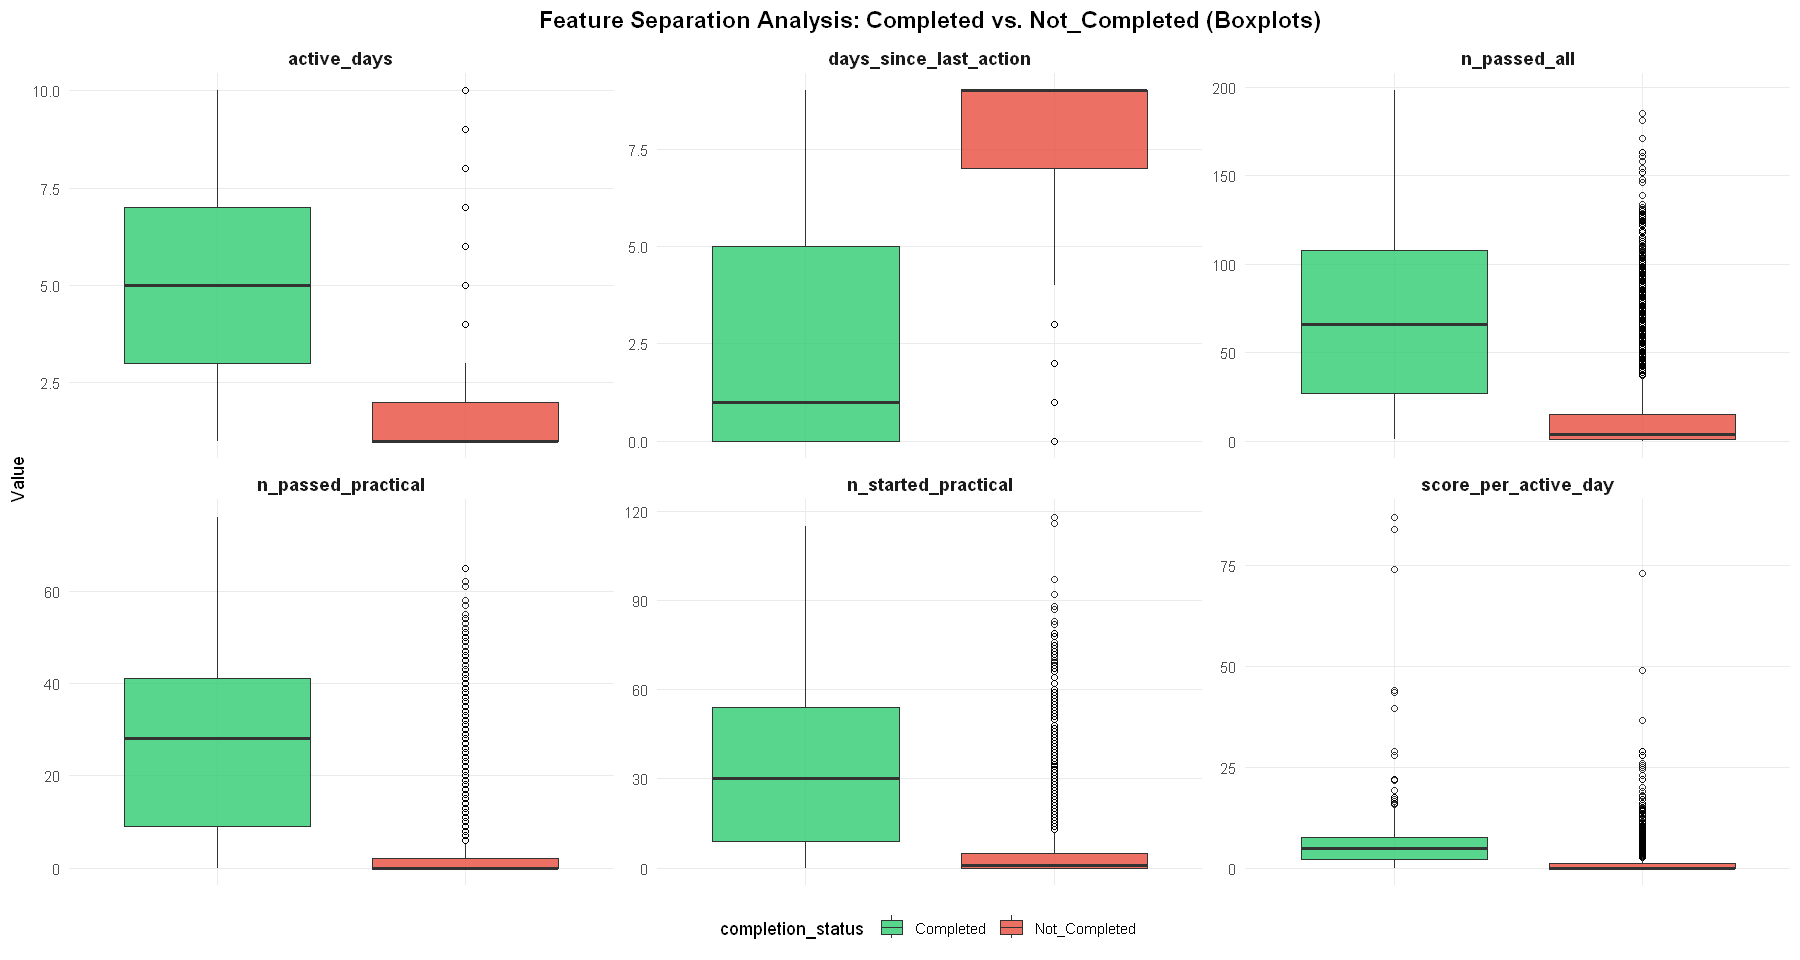

In [38]:
# Output size
options(repr.plot.width = 15, repr.plot.height = 8)

# Boxplot grid for class-wise feature comparison
ggplot(plot_data, aes(x = completion_status, y = value, fill = completion_status)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "black", outlier.shape = 1) +
  facet_wrap(~ feature, scales = "free", ncol = 3) +
  scale_fill_manual(
    values = c("Completed" = "#2ecc71", "Not_Completed" = "#e74c3c"),
    labels = c("Completed", "Not_Completed")
  ) +
  theme_minimal() +
  labs(
    title = "Feature Separation Analysis: Completed vs. Not_Completed (Boxplots)",
    x = NULL,
    y = "Value"
  ) +
  theme(
    legend.position = "bottom",
    strip.text = element_text(face = "bold", size = 11),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    axis.text.x = element_blank()
  )

**Visual Interpretation: Feature Separation**

The boxplots confirm clear class-wise differences across the selected early behavioral features. Users who eventually completed the course show substantially higher early activity, stronger practical engagement, and higher per-day productivity, while `Not_Completed` users remain concentrated near low or zero values for most activity and progress features.

The clearest visual separation appears in `n_passed_all`, `n_passed_practical`, `n_started_practical`, `score_per_active_day`, and `days_since_last_action`. For `days_since_last_action`, lower values indicate more recent activity, so the lower distribution for `Completed` users suggests that future completers remain active closer to the end of the 10-day observation window.

These plots are used as descriptive visual evidence, not as a formal feature-ranking method. They reinforce the conclusion that **early practical activation, sustained engagement, productivity, and recent activity** are among the strongest indicators of eventual course completion.


---

### Feature Correlation Review

> **Technical Note: Correlation Review**
>
> This block reviews pairwise correlations among training-set predictors before model training.
>
> The goal is diagnostic rather than automatic feature removal. Tree-based models can handle correlated predictors, but strong correlations are still useful for interpreting redundancy, feature importance, and progress-proxy behavior.

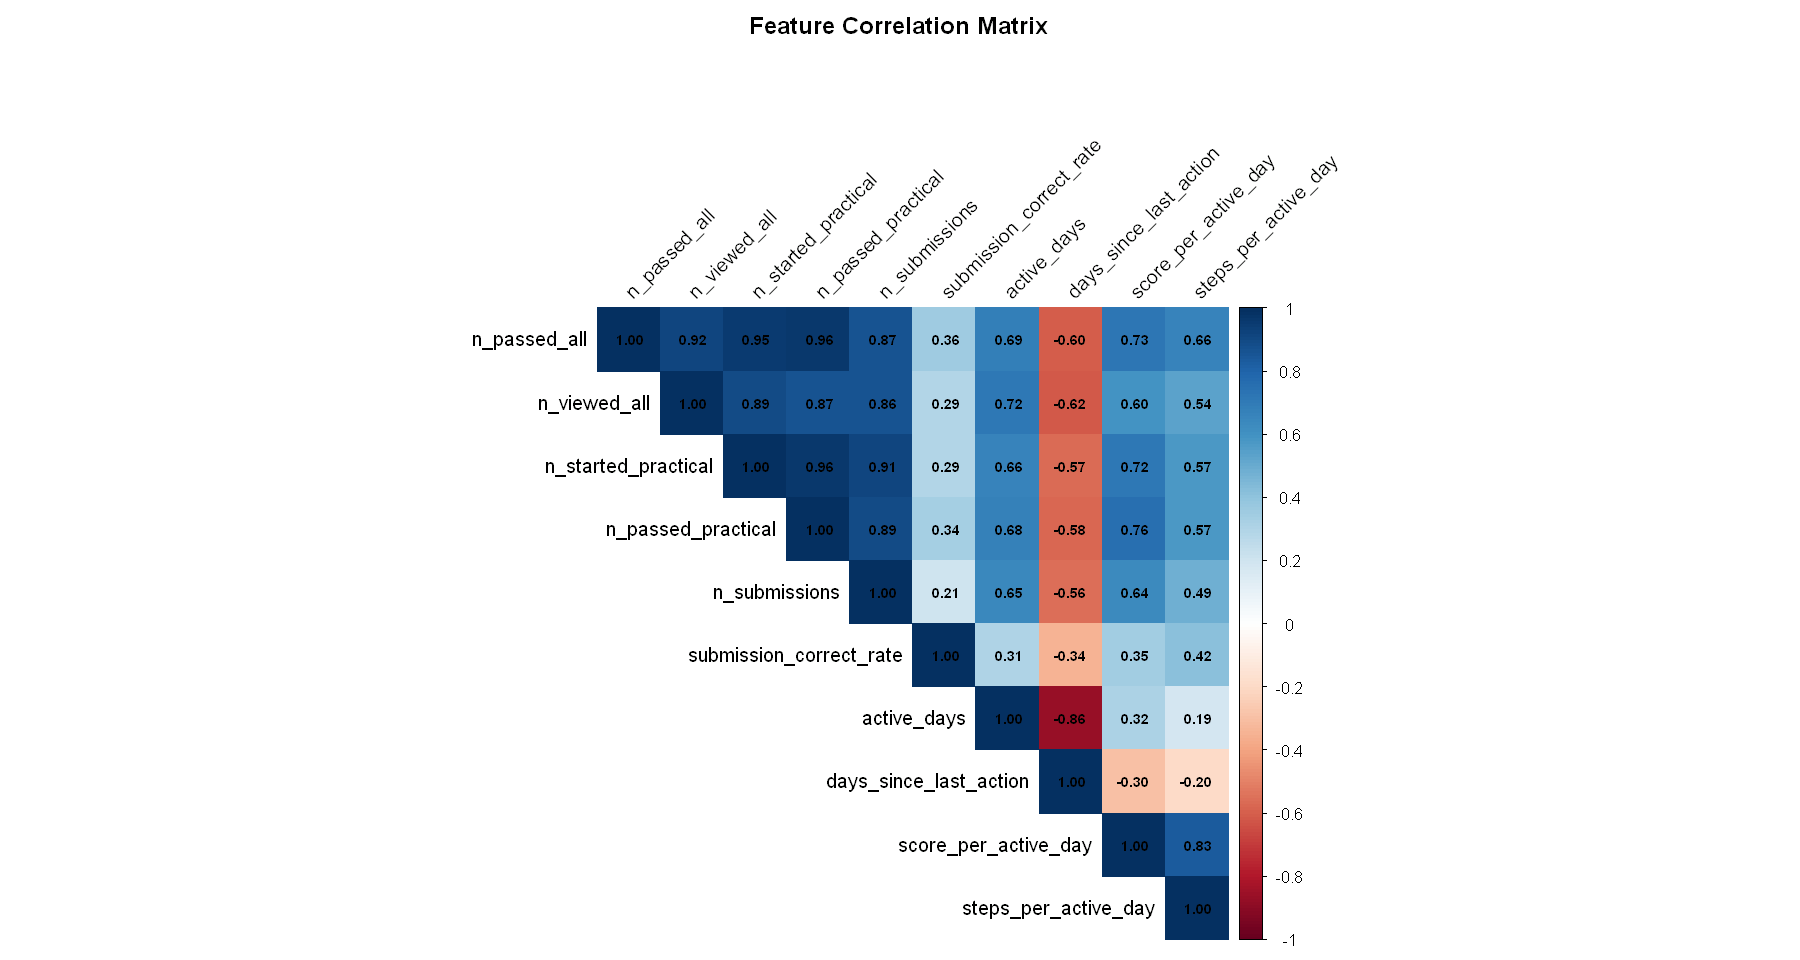

In [39]:
# Correlation matrix of training predictors
cor_matrix <- cor(train_data[, ..features], use = "complete.obs")

# Visualize correlation matrix once
corrplot(
  cor_matrix,
  method = "color",
  type = "upper",
  tl.col = "black",
  tl.srt = 45,
  addCoef.col = "black",
  number.cex = 0.7,
  title = "Feature Correlation Matrix",
  mar = c(0, 0, 2, 0)   # bottom, left, top, right
)

In [40]:
# Identify highly correlated feature pairs
high_cor_idx <- which(
  abs(cor_matrix) > 0.9 & upper.tri(cor_matrix),
  arr.ind = TRUE
)

# Convert highly correlated predictor pairs into a readable summary table
# for redundancy review before model training.
high_cor_pairs <- data.table(
  feature_1 = rownames(cor_matrix)[high_cor_idx[, 1]],
  feature_2 = colnames(cor_matrix)[high_cor_idx[, 2]],
  correlation = cor_matrix[high_cor_idx]
)

# Display highly correlated pairs
high_cor_pairs

feature_1,feature_2,correlation
<chr>,<chr>,<dbl>
n_passed_all,n_viewed_all,0.9151386
n_passed_all,n_started_practical,0.9508039
n_passed_all,n_passed_practical,0.9605954
n_started_practical,n_passed_practical,0.9626641
n_started_practical,n_submissions,0.9125666


**Interpretation: Feature Correlation Review**

The correlation matrix shows strong positive relationships among early activity and practical-engagement features. Five predictor pairs exceed the **0.90** threshold, with the strongest correlation observed between `n_started_practical` and `n_passed_practical` (`r` ≈ **0.962**).

A strong negative correlation between `active_days` and `days_since_last_action` is also behaviorally expected: users with more active days tend to remain active more recently, which results in lower recency-gap values.

Overall, the feature set contains meaningful dependence, but not enough redundancy to justify automatic feature removal before initial tree-based model training. These correlations are retained as useful context for interpreting feature importance and progress-proxy behavior.

---

**Training-Set EDA Summary: Progress-Aware Signals**

Across the training-set EDA, the same pattern emerges consistently within the **progress-aware feature space**: eventual completers show stronger early activity, greater practical engagement, higher productivity, and more recent activity.

The strongest early signals are concentrated in practical-progress and overall activity features. Because completion is score-based, pass-, score-, and success-related predictors should be interpreted as early progress signals aligned with the completion threshold, not as fully leakage-free independent predictors.

The correlation review does not justify automatic feature removal at this stage, so the full progress-aware predictor set is retained for baseline completion modeling.

The later leakage-reduced engagement-only robustness check evaluates whether meaningful predictive signal remains after removing direct score/progress proxy features.

---

## Shared Target Setup and Evaluation Helpers

> **Technical Note: Shared Evaluation Helpers**
>
> This section defines the common target setup and reusable evaluation functions used across all supervised model variants.
>
> `Completed` is treated as the positive class because it is the rare outcome. Therefore, threshold-based metrics, ROC-AUC, and PR-AUC are calculated for `Completed`.
>
> The helper functions cover threshold-based metrics, ROC-AUC and PR-AUC, validation-based threshold selection, final test evaluation, risk-ranking diagnostics using `Risk_Not_Completed = 1 - P(Completed)`, and probability calibration checks.
>
> Using the same helper functions across progress-aware, ablation, and engagement-only models keeps the evaluation logic consistent. The feature set changes across experiments, but the target definition and metric logic remain the same.

### Shared Target and Feature Setup

In [41]:
# Define the positive class used for model evaluation
positive_class <- "Completed"
target_levels <- c("Completed", "Not_Completed")

# Ensure consistent factor levels across all data splits
train_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]
val_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]
test_data[, completion_status := factor(as.character(completion_status), levels = target_levels)]

# Define predictor columns by excluding the target variable
features <- setdiff(names(train_data), "completion_status")

---

### Core Metric Helpers

In [42]:
# Replace missing metric values with 0
clean_na <- function(x) {
  ifelse(is.na(x), 0, x)
}

In [43]:
# Compute threshold-based classification metrics for a given probability cutoff
get_threshold_metrics <- function(probs,
                                  truth,
                                  threshold,
                                  positive_class = "Completed",
                                  target_levels = c("Completed", "Not_Completed")) {
  
  # Keep target levels consistent with the positive-class setup
  truth <- factor(as.character(truth), levels = target_levels)
  negative_class <- setdiff(levels(truth), positive_class)
  
  stopifnot(length(negative_class) == 1)
  
  # Convert predicted probabilities into class labels using the selected threshold
  preds <- factor(
    ifelse(probs >= threshold, positive_class, negative_class),
    levels = levels(truth)
  )
  
  # Build confusion matrix with `Completed` as the positive class
  conf <- caret::confusionMatrix(
    data = preds,
    reference = truth,
    positive = positive_class
  )
  
  # Extract the core metrics needed for F-scores and error-rate diagnostics
  recall <- clean_na(as.numeric(conf$byClass["Sensitivity"]))
  precision <- clean_na(as.numeric(conf$byClass["Pos Pred Value"]))
  specificity <- clean_na(as.numeric(conf$byClass["Specificity"]))
  
  # F1 balances precision and recall equally
  f1 <- ifelse(
    precision + recall == 0,
    0,
    2 * precision * recall / (precision + recall)
  )
  
  # F2 gives more weight to recall, which is useful under rare-class detection
  beta <- 2
  
  f2 <- ifelse(
    (beta^2 * precision + recall) == 0,
    0,
    (1 + beta^2) * precision * recall /
      ((beta^2 * precision) + recall)
  )
  
  # Return both positive-class metrics and error-rate diagnostics
  data.table(
    Threshold   = threshold,
    Recall      = recall,
    Precision   = precision,
    Specificity = specificity,
    F1          = f1,
    F2          = f2,
    FPR         = 1 - specificity,
    FNR         = 1 - recall
  )
}

In [44]:
# Compute threshold-independent ranking metrics
get_auc_metrics <- function(probs,
                            truth,
                            positive_class = "Completed") {
  
  # Convert the target into binary format required by ROC-AUC and PR-AUC
  y_true <- ifelse(truth == positive_class, 1, 0)
  
  # ROC-AUC evaluates overall ranking quality across all thresholds
  roc_auc <- as.numeric(
    pROC::roc(
      response = y_true,
      predictor = probs,
      quiet = TRUE
    )$auc
  )
  
  # PR-AUC is especially informative under strong class imbalance
  pr_auc <- MLmetrics::PRAUC(
    y_pred = probs,
    y_true = y_true
  )
  
  # Return rounded threshold-independent metrics
  data.table(
    ROC_AUC = round(roc_auc, 4),
    PR_AUC  = round(pr_auc, 4)
  )
}

---

### Validation and Final Test Evaluation Helpers

In [45]:
# Evaluate validation performance and select the best threshold
# according to the chosen optimization metric.
evaluate_validation_model <- function(probs_val,
                                      val_truth,
                                      optimize_metric = c("F1", "F2", "Recall", "Precision"),
                                      threshold_grid = seq(0.01, 0.99, by = 0.01),
                                      positive_class = "Completed") {
  
  optimize_metric <- match.arg(optimize_metric)
  
  y_true_val <- ifelse(val_truth == positive_class, 1, 0)
  
  # Compute validation ROC-AUC
  val_roc_auc <- as.numeric(
    pROC::roc(
      response = y_true_val,
      predictor = probs_val,
      quiet = TRUE
    )$auc
  )
  
  # Compute validation PR-AUC
  val_pr_auc <- MLmetrics::PRAUC(
    y_pred = probs_val,
    y_true = y_true_val
  )
  
  # Evaluate all candidate thresholds
  val_threshold_metrics <- rbindlist(lapply(threshold_grid, function(t) {
    get_threshold_metrics(
      probs = probs_val,
      truth = val_truth,
      threshold = t,
      positive_class = positive_class
    )
  }))
  
  # Select the threshold with the best target metric
  val_threshold_metrics <- val_threshold_metrics[
    order(-val_threshold_metrics[[optimize_metric]], Threshold)
  ]
  
  best_row <- val_threshold_metrics[1]
  
  # Return compact validation summary
  data.table(
    Optimize_By = optimize_metric,
    Val_Threshold = best_row$Threshold,
    Val_ROC_AUC = val_roc_auc,
    Val_PR_AUC = val_pr_auc,
    Val_Best_Metric = best_row[[optimize_metric]],
    Val_Recall = best_row$Recall,
    Val_Precision = best_row$Precision,
    Val_F1 = best_row$F1,
    Val_F2 = best_row$F2,
    Val_Specificity = best_row$Specificity,
    Val_FPR = best_row$FPR,
    Val_FNR = best_row$FNR
)
}

In [46]:
# Evaluate final test performance using a fixed validation-selected threshold.
evaluate_final_test_model <- function(probs_test,
                                      test_truth,
                                      threshold,
                                      positive_class = "Completed") {
  
  # Compute threshold-based test metrics
  test_threshold_metrics <- get_threshold_metrics(
    probs = probs_test,
    truth = test_truth,
    threshold = threshold,
    positive_class = positive_class
  )
  
  # Compute threshold-independent test metrics
  test_auc_metrics <- get_auc_metrics(
    probs = probs_test,
    truth = test_truth,
    positive_class = positive_class
  )
  
  # Return compact final test summary
  data.table(
    Threshold = threshold,
    Test_ROC_AUC = test_auc_metrics$ROC_AUC,
    Test_PR_AUC = test_auc_metrics$PR_AUC,
    Test_Recall = round(test_threshold_metrics$Recall, 3),
    Test_Precision = round(test_threshold_metrics$Precision, 3),
    Test_F1 = round(test_threshold_metrics$F1, 3),
    Test_F2 = round(test_threshold_metrics$F2, 3),
    Test_Specificity = round(test_threshold_metrics$Specificity, 3),
    Test_FPR = round(test_threshold_metrics$FPR, 3),
    Test_FNR = round(test_threshold_metrics$FNR, 3)
  )
}

---

### Risk and Completion Ranking Policy Helpers

In [47]:
# Build high-risk prioritization table using predicted P(Completed)
get_risk_policy_table <- function(model_id,
                                  probs_completed,
                                  truth,
                                  policy_shares = c(0.05, 0.10, 0.20, 0.30),
                                  positive_class = "Completed") {
  
  # Convert completion probability into non-completion risk score
  policy_data <- data.table(
    P_Completed = probs_completed,
    Risk_Not_Completed = 1 - probs_completed,
    Actual_Completed = as.integer(truth == positive_class),
    Actual_Not_Completed = as.integer(truth != positive_class)
  )
  
  # Baseline rates are used as reference points for targeted risk groups
  baseline_completion_rate <- mean(policy_data$Actual_Completed)
  baseline_non_completion_rate <- mean(policy_data$Actual_Not_Completed)
  
  n_total <- nrow(policy_data)
  
  policy_results <- rbindlist(lapply(policy_shares, function(share) {
    
    # Select the top X% users with the highest estimated non-completion risk
    n_target <- ceiling(n_total * share)
    
    targeted_users <- policy_data[
      order(-Risk_Not_Completed)
    ][1:n_target]
    
    completion_rate <- mean(targeted_users$Actual_Completed)
    non_completion_rate <- mean(targeted_users$Actual_Not_Completed)
    
    # Summarize how concentrated non-completion is within the targeted group
    data.table(
      Model_ID = model_id,
      Policy = paste0("Top ", share * 100, "% highest risk"),
      Users = n_target,
      Completion_Rate = round(completion_rate, 4),
      Baseline_Completion_Rate = round(baseline_completion_rate, 4),
      Completion_Reduction = round(baseline_completion_rate - completion_rate, 4),
      Non_Completion_Rate = round(non_completion_rate, 4),
      Baseline_Non_Completion_Rate = round(baseline_non_completion_rate, 4),
      Non_Completion_Lift = round(non_completion_rate / baseline_non_completion_rate, 3),
      Completed_Users = sum(targeted_users$Actual_Completed),
      Not_Completed_Users = sum(targeted_users$Actual_Not_Completed)
    )
  }))
  
  return(policy_results)
}

In [48]:
# Build complementary diagnostic for users with the strongest completion signal
get_completion_priority_table <- function(model_id,
                                          probs_completed,
                                          truth,
                                          policy_shares = c(0.05, 0.10, 0.20, 0.30),
                                          positive_class = "Completed") {
  
  policy_data <- data.table(
    P_Completed = probs_completed,
    Risk_Not_Completed = 1 - probs_completed,
    Actual_Completed = as.integer(truth == positive_class),
    Actual_Not_Completed = as.integer(truth != positive_class)
  )
  
  # Baseline completion rate is used to calculate completion lift
  baseline_completion_rate <- mean(policy_data$Actual_Completed)
  n_total <- nrow(policy_data)
  
  completion_priority_results <- rbindlist(lapply(policy_shares, function(share) {
    
    # Select the top X% users with the highest predicted completion probability
    n_segment <- ceiling(n_total * share)
    
    high_completion_users <- policy_data[
      order(-P_Completed)
    ][1:n_segment]
    
    # Compare completion concentration in the selected segment against baseline
    data.table(
      Model_ID = model_id,
      Segment = paste0("Top ", share * 100, "% highest P(Completed)"),
      Users = n_segment,
      Completion_Rate = round(mean(high_completion_users$Actual_Completed), 4),
      Baseline_Completion_Rate = round(baseline_completion_rate, 4),
      Completion_Lift = round(
        mean(high_completion_users$Actual_Completed) / baseline_completion_rate,
        3
      )
    )
  }))
  
  return(completion_priority_results)
}

---

### Calibration Helpers

In [49]:
# Build the calibration table for the selected model
get_calibration_table <- function(model_id,
                                  probs_completed,
                                  truth,
                                  positive_class = "Completed",
                                  breaks = c(0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00)) {
  
  calibration_data <- data.table(
    Model_ID = model_id,
    P_Completed = probs_completed,
    Actual_Completed = as.integer(truth == positive_class)
  )
  
  # Group predicted probabilities into predefined probability intervals
  calibration_data[, Probability_Bin := cut(
    P_Completed,
    breaks = breaks,
    include.lowest = TRUE,
    right = TRUE
  )]
  
  # Compare mean predicted probability with the actual completion rate per bin
  calibration_table <- calibration_data[, .(
    Users = .N,
    Mean_P_Completed = round(mean(P_Completed), 4),
    Actual_Completion_Rate = round(mean(Actual_Completed), 4),
    Calibration_Gap = round(mean(P_Completed) - mean(Actual_Completed), 4)
  ), by = .(Model_ID, Probability_Bin)]
  
  calibration_table <- calibration_table[
    order(Model_ID, Probability_Bin)
  ]
  
  return(calibration_table)
}

In [50]:
# Compute the Brier Score as a measure of overall probabilistic accuracy.
# Lower values indicate smaller squared differences between predicted
# probabilities and observed binary outcomes.
get_brier_score <- function(model_id,
                            probs_completed,
                            truth,
                            positive_class = "Completed") {
  
  actual_completed <- as.integer(truth == positive_class)
  
  data.table(
    Model_ID = model_id,
    Brier_Score = round(mean((probs_completed - actual_completed)^2), 5),
    Mean_P_Completed = round(mean(probs_completed), 4),
    Actual_Completion_Rate = round(mean(actual_completed), 4)
  )
}

---

## Reusable Model Training Functions

> **Technical Note: Reusable Model Training Logic**
>
> This block defines reusable wrappers for training and validating Random Forest and XGBoost models.
>
> The same functions are reused across feature sets to keep model comparison consistent. The implemented strategies include baseline models, class weighting, 1:3 resampling, and 1:1 resampling.

### Random Forest Training Wrapper

In [51]:
# Train one Random Forest strategy and evaluate it on the validation set
train_evaluate_rf_validation <- function(strategy_id,
                                         train_input,
                                         val_input,
                                         feature_cols,
                                         feature_set_name,
                                         classwt = NULL,
                                         sampsize = NULL,
                                         optimize_metric = "F2") {
  
  set.seed(42)
  
  # Base Random Forest configuration shared by all RF strategies
  rf_args <- list(
    x = train_input[, ..feature_cols],
    y = train_input$completion_status,
    ntree = 500,
    mtry = floor(sqrt(length(feature_cols))),
    importance = TRUE
  )
  
  # Optional class weighting for imbalance-aware RF models
  if (!is.null(classwt)) {
    rf_args$classwt <- classwt
  }
  
  # Optional stratified sampling for resampled RF models
  if (!is.null(sampsize)) {
    rf_args$strata <- train_input$completion_status
    rf_args$sampsize <- sampsize
  }
  
  # Train RF using the selected strategy-specific arguments
  rf_fit <- do.call(randomForest::randomForest, rf_args)
  
  # Predict validation probabilities for the positive class
  rf_probs_val <- predict(
    rf_fit,
    newdata = val_input[, ..feature_cols],
    type = "prob"
  )[, positive_class]
  
  # Evaluate validation performance and select the best threshold
  rf_result <- evaluate_validation_model(
    probs_val = rf_probs_val,
    val_truth = val_input$completion_status,
    optimize_metric = optimize_metric,
    positive_class = positive_class
  )
  
  # Add metadata for later comparison across feature sets and strategies
  rf_result[, `:=`(
    Feature_Set = feature_set_name,
    Model_ID = strategy_id
  )]
  
  return(list(
    model = rf_fit,
    result = rf_result
  ))
}

---

### XGBoost: Data Preparation Helpers & Training Wrapper

In [52]:
# Binary target label for XGBoost: Completed = 1, otherwise = 0
make_xgb_label_validation <- function(data) {
  ifelse(data$completion_status == positive_class, 1, 0)
}

In [53]:
# XGBoost helper: converts a data.table into DMatrix format with binary labels
make_xgb_dmatrix_generic <- function(data, feature_cols) {
  
  # Convert selected predictors into the numeric matrix required by XGBoost
  x <- data.matrix(data[, ..feature_cols])
  
  # Create binary target label: Completed = 1, otherwise = 0
  y <- make_xgb_label_validation(data)
  
  xgboost::xgb.DMatrix(
    data = x,
    label = y
  )
}

In [54]:
# XGBoost helper: creates a downsampled training set with a fixed negative-to-positive ratio
make_xgb_resampled_train_generic <- function(train_input,
                                             negative_to_positive_ratio = 3) {
  
  set.seed(42)
  
  # Keep all positive cases and sample only from the majority class
  positive_idx <- which(train_input$completion_status == positive_class)
  negative_idx <- which(train_input$completion_status != positive_class)
  
  n_positive <- length(positive_idx)
  
  # Limit the number of negative cases according to the requested ratio
  n_negative_sample <- min(
    length(negative_idx),
    negative_to_positive_ratio * n_positive
  )
  
  sampled_negative_idx <- sample(
    negative_idx,
    size = n_negative_sample,
    replace = FALSE
  )
  
  # Combine positives with sampled negatives and shuffle row order
  sampled_idx <- sample(c(positive_idx, sampled_negative_idx))
  
  train_input[sampled_idx]
}

In [55]:
# XGBoost helper: train one validation-stage XGBoost strategy and return the model plus metrics
train_evaluate_xgb_validation <- function(strategy_id,
                                          train_input,
                                          val_input,
                                          feature_cols,
                                          feature_set_name,
                                          scale_pos_weight = NULL,
                                          optimize_metric = "F2") {
  
  # Convert train and validation sets to XGBoost's DMatrix format
  dtrain <- make_xgb_dmatrix_generic(train_input, feature_cols)
  dval   <- make_xgb_dmatrix_generic(val_input, feature_cols)
  
  # Shared baseline XGBoost configuration for comparable model strategies
  xgb_params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    eta = 0.05,
    max_depth = 4,
    min_child_weight = 1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    nthread = 1
  )
  
  # Optional class weighting for imbalance-aware XGBoost variants
  if (!is.null(scale_pos_weight)) {
    xgb_params$scale_pos_weight <- scale_pos_weight
  }
  
  set.seed(42)
  
  # Train model with validation monitoring and early stopping
  xgb_fit <- xgboost::xgb.train(
  params = xgb_params,
  data = dtrain,
  nrounds = 500,
  evals = list(train = dtrain, val = dval),
  callbacks = list(
    xgboost::xgb.cb.early.stop(
      stopping_rounds = 30,
      maximize = TRUE,
      metric_name = "val_aucpr",
      verbose = FALSE,
      save_best = TRUE
    )
  ),
  verbose = 0
)
  
  # Predict validation probabilities for the positive class
  xgb_probs_val <- predict(xgb_fit, dval)
  
  # Evaluate validation metrics and select the best threshold
  xgb_result <- evaluate_validation_model(
    probs_val = xgb_probs_val,
    val_truth = val_input$completion_status,
    optimize_metric = optimize_metric,
    positive_class = positive_class
  )
  
  # Attach metadata for later comparison across strategies and feature sets
  xgb_result[, `:=`(
    Feature_Set = feature_set_name,
    Model_ID = strategy_id
  )]
  
  return(list(
    model = xgb_fit,
    result = xgb_result
  ))
}

---

### Baseline Strategy Runner

In [56]:
# Run all baseline RF and XGBoost strategies on one feature set
run_all_model_strategies_validation <- function(train_input,
                                                val_input,
                                                feature_cols,
                                                feature_set_name,
                                                optimize_metric = "F2") {
  
  # Containers for trained model objects and validation result tables
  models <- list()
  results <- list()
  
  # ============================================================
  # Random Forest imbalance setup
  # ============================================================
  
  # Count target classes to derive class weights and sampling sizes
  rf_class_counts <- table(train_input$completion_status)
  
  negative_class <- setdiff(
    levels(train_input$completion_status),
    positive_class
  )
  
  stopifnot(length(negative_class) == 1)
  
  n_pos <- as.integer(rf_class_counts[positive_class])
  n_neg <- as.integer(rf_class_counts[negative_class])
  
  # Inverse-frequency class weights for weighted RF
  rf_class_weights <- sum(rf_class_counts) /
    (length(rf_class_counts) * rf_class_counts)
  
  rf_class_weights <- as.numeric(rf_class_weights)
  names(rf_class_weights) <- names(rf_class_counts)
  
  # Stratified RF sampling: draw n_pos observations from the Completed
  # stratum and up to 3 * n_pos observations from the negative stratum per tree
  rf_sampsize_1_3 <- setNames(
    integer(length(levels(train_input$completion_status))),
    levels(train_input$completion_status)
  )
  
  rf_sampsize_1_3[positive_class] <- n_pos
  rf_sampsize_1_3[negative_class] <- min(n_neg, 3 * n_pos)
  
  # Stratified RF sampling: draw equal-sized class samples per tree
  rf_sampsize_1_1 <- setNames(
    integer(length(levels(train_input$completion_status))),
    levels(train_input$completion_status)
  )
  
  rf_sampsize_1_1[positive_class] <- n_pos
  rf_sampsize_1_1[negative_class] <- min(n_neg, n_pos)
  
  
  # ============================================================
  # Random Forest strategy comparison
  # ============================================================
  
  # Baseline RF without explicit imbalance handling
  rf_baseline <- train_evaluate_rf_validation(
    strategy_id = "RF_Baseline",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Baseline"]] <- rf_baseline$model
  results[["RF_Baseline"]] <- rf_baseline$result
  
  
  # Weighted RF using inverse-frequency class weights
  rf_weighted <- train_evaluate_rf_validation(
    strategy_id = "RF_Weighted",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    classwt = rf_class_weights,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Weighted"]] <- rf_weighted$model
  results[["RF_Weighted"]] <- rf_weighted$result
  
  
  # RF with moderate negative-class downsampling
  rf_resampled_1_3 <- train_evaluate_rf_validation(
    strategy_id = "RF_Resampled_1_3",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    sampsize = rf_sampsize_1_3,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Resampled_1_3"]] <- rf_resampled_1_3$model
  results[["RF_Resampled_1_3"]] <- rf_resampled_1_3$result
  
  
  # RF with balanced 1:1 class sampling
  rf_resampled_1_1 <- train_evaluate_rf_validation(
    strategy_id = "RF_Resampled_1_1",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    sampsize = rf_sampsize_1_1,
    optimize_metric = optimize_metric
  )
  
  models[["RF_Resampled_1_1"]] <- rf_resampled_1_1$model
  results[["RF_Resampled_1_1"]] <- rf_resampled_1_1$result
  
  
  # ============================================================
  # XGBoost imbalance setup
  # ============================================================
  
  # Convert target to binary labels for XGBoost-specific imbalance handling
  y_train <- make_xgb_label_validation(train_input)
  
  xgb_n_pos <- sum(y_train == 1)
  xgb_n_neg <- sum(y_train == 0)
  
  # Class weight for weighted XGBoost
  xgb_scale_pos_weight <- xgb_n_neg / xgb_n_pos
  
  # Resampled XGBoost training sets with different negative-to-positive ratios
  xgb_train_1_3 <- make_xgb_resampled_train_generic(
    train_input = train_input,
    negative_to_positive_ratio = 3
  )
  
  xgb_train_1_1 <- make_xgb_resampled_train_generic(
    train_input = train_input,
    negative_to_positive_ratio = 1
  )
  
  
  # ============================================================
  # XGBoost strategy comparison
  # ============================================================
  
  # Baseline XGBoost without explicit imbalance handling
  xgb_baseline <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Baseline",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Baseline"]] <- xgb_baseline$model
  results[["XGB_Baseline"]] <- xgb_baseline$result
  
  
  # Weighted XGBoost using scale_pos_weight
  xgb_weighted <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Weighted",
    train_input = train_input,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = xgb_scale_pos_weight,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Weighted"]] <- xgb_weighted$model
  results[["XGB_Weighted"]] <- xgb_weighted$result
  
  
  # XGBoost trained on a 1:3 resampled training set
  xgb_resampled_1_3 <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Resampled_1_3",
    train_input = xgb_train_1_3,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Resampled_1_3"]] <- xgb_resampled_1_3$model
  results[["XGB_Resampled_1_3"]] <- xgb_resampled_1_3$result
  
  
  # XGBoost trained on a balanced 1:1 resampled training set
  xgb_resampled_1_1 <- train_evaluate_xgb_validation(
    strategy_id = "XGB_Resampled_1_1",
    train_input = xgb_train_1_1,
    val_input = val_input,
    feature_cols = feature_cols,
    feature_set_name = feature_set_name,
    scale_pos_weight = NULL,
    optimize_metric = optimize_metric
  )
  
  models[["XGB_Resampled_1_1"]] <- xgb_resampled_1_1$model
  results[["XGB_Resampled_1_1"]] <- xgb_resampled_1_1$result
  
  
  # ============================================================
  # Aggregate validation results
  # ============================================================
  
  # Combine all validation result rows into one comparison table
  results_table <- rbindlist(
    results,
    use.names = TRUE,
    fill = TRUE
  )
  
  # Standardize column order for compact reporting
  setcolorder(
    results_table,
    c(
      "Feature_Set",
      "Model_ID",
      "Optimize_By",
      "Val_Threshold",
      "Val_Best_Metric",
      "Val_ROC_AUC",
      "Val_PR_AUC",
      "Val_Recall",
      "Val_Precision",
      "Val_F1",
      "Val_F2",
      "Val_Specificity",
      "Val_FPR",
      "Val_FNR"
    )
  )
  
  # Sort primarily by ranking quality, then by threshold-based F2
  # and lower false-positive rate.
  results_table <- results_table[order(-Val_PR_AUC,-Val_F2,Val_FPR)]
  
  return(list(
  models = models,
  results = results_table,
  sampling = list(
    rf_sampsize_1_1 = rf_sampsize_1_1,
    rf_sampsize_1_3 = rf_sampsize_1_3,
    rf_class_weights = rf_class_weights,
    xgb_scale_pos_weight = xgb_scale_pos_weight
  )
))
}

---

## Baseline Results Aggregation

### Progress-Aware Baseline Model Training on Original Features

> **Technical Note: Original Feature Baseline**
>
> This baseline uses the full original 10-day feature set, including early progress and score-related variables. Therefore, it represents the **progress-aware prediction setting**.

In [57]:
# Run baseline model comparison on the original progress-aware feature set
original_comparison <- run_all_model_strategies_validation(
  train_input = train_data,
  val_input = val_data,
  feature_cols = features,
  feature_set_name = "Original",
  optimize_metric = "F2"
)

# Store trained baseline models for later inspection or comparison
models_original <- original_comparison$models

# Store validation results from the original-feature baseline comparison
baseline_results_validation <- original_comparison$results

In [58]:
# Create a compact validation summary for reporting
baseline_results_compact <- baseline_results_validation[
  ,
  .(
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC   = Val_ROC_AUC,
    PR_AUC    = Val_PR_AUC,
    Recall    = Val_Recall,
    Precision = Val_Precision,
    F2        = Val_F2,
    FPR       = Val_FPR
  )
]

# Display compact baseline comparison table
baseline_results_compact

Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline,0.09,0.9070456,0.58904549,0.7081545,0.36912752,0.5982596,0.08294118
XGB_Weighted,0.57,0.9071024,0.57409177,0.7596567,0.34368932,0.6116102,0.09941176
RF_Resampled_1_3,0.37,0.8883363,0.56575548,0.6824034,0.37588652,0.5867159,0.07764706
XGB_Resampled_1_1,0.58,0.9022924,0.55605104,0.7682403,0.31625442,0.5974633,0.11382353
RF_Resampled_1_1,0.57,0.8964807,0.55299350,0.7081545,0.35791757,0.5922469,0.08705882
RF_Baseline,0.18,0.8742527,0.55271001,0.6566524,0.41018767,0.5862069,0.06470588
XGB_Resampled_1_3,0.37,0.9088147,0.52834343,0.7167382,0.37193764,0.6046343,0.08294118
RF_Weighted,0.08,0.5701344,0.09121512,0.8369099,0.08705357,0.3073770,0.60147059


**Result Summary: Progress-Aware Baseline Models**

This baseline comparison belongs to the **progress-aware prediction setting**. It uses the original 10-day feature set, including early activity, practical engagement, progress, submission, productivity, and recency variables.

The models predict `P(Completed)` with `Completed` treated as the positive class. For business use, this score is later inverted into:

`Risk_Not_Completed = 1 - P(Completed)`

Therefore, validation F2 and Recall measure completion-signal detection, while later retention analysis focuses on users at the opposite end of the probability distribution: those with the lowest `P(Completed)`.

At this stage, no final model is selected. The table is used as a validation-development diagnostic before feature engineering and targeted tuning.

| Baseline role | Model_ID | Interpretation |
|---|---|---|
| Strongest threshold-based baseline | `XGB_Weighted` | Highest baseline F2, but requires comparison after feature engineering and tuning. |
| Strongest ranking baseline | `XGB_Baseline` | Highest baseline PR-AUC and strongest initial candidate for probability-based ranking. |
| Random Forest benchmarks | `RF_Resampled_1_1` / `RF_Resampled_1_3` | Retained as model-family benchmarks for comparison with XGBoost. |
| Weak baseline candidate | `RF_Weighted` | Not competitive due to very low PR-AUC and very high FPR. |

**Modeling Implication**

The original progress-aware feature set already contains strong predictive signal. However, these results are not used for final model selection. Final decisions are made after feature engineering, targeted tuning diagnostics, and validation-based model selection.

---

## Feature Engineering

> **Technical Note: Progress-Aware Feature Engineering**
>
> Feature engineering enriches the original 10-day feature set with interpretable activation, ratio/intensity, practice, and recency signals linked to the Activation Gap.
>
> This step belongs to the **progress-aware prediction setting**: all features are calculated within the first 10 days, but some pass-, submission-, success-, and productivity-related variables may still act as progress-based target proxies because completion is score-based.
>
> Direct score/progress proxy features are later removed in the leakage-reduced engagement-only robustness check.

### Create and Apply Engineered Features

In [59]:
# Add engineered activation, ratio, and intensity features
add_engineered_features <- function(data) {
  
  data_engineered <- copy(data)
  
  # Binary activation flags
  data_engineered[, has_started_practical := as.integer(n_started_practical > 0)]
  data_engineered[, has_submitted := as.integer(n_submissions > 0)]
  data_engineered[, has_passed_practical := as.integer(n_passed_practical > 0)]
  data_engineered[, is_recently_active := as.integer(days_since_last_action <= 2)]
  
  # Practical activation intensity relative to viewed steps
  data_engineered[, started_practical_per_viewed_step := fifelse(
    n_viewed_all > 0,
    n_started_practical / n_viewed_all,
    0
  )]
  
  # Practical success rate among started practical steps
  data_engineered[, practical_pass_rate := fifelse(
    n_started_practical > 0,
    n_passed_practical / n_started_practical,
    0
  )]
  
  # Submission intensity per started practical step
  data_engineered[, submissions_per_started_practical := fifelse(
    n_started_practical > 0,
    n_submissions / n_started_practical,
    0
  )]
  
  # Overall progress intensity relative to viewed steps
  data_engineered[, passed_per_viewed_step := fifelse(
    n_viewed_all > 0,
    n_passed_all / n_viewed_all,
    0
  )]
  
  # Submission and practical-start intensity per active day
  data_engineered[, submissions_per_active_day := fifelse(
    active_days > 0,
    n_submissions / active_days,
    0
  )]
  
  data_engineered[, practical_starts_per_active_day := fifelse(
    active_days > 0,
    n_started_practical / active_days,
    0
  )]
  
  return(data_engineered)
}

In [60]:
# Apply the same feature-engineering logic to train and validation sets
train_data_engineered <- add_engineered_features(train_data)
val_data_engineered   <- add_engineered_features(val_data)

In [61]:
# Define engineered feature set
features_engineered <- setdiff(
  names(train_data_engineered),
  "completion_status"
)

# Identify newly created features only
engineered_cols <- setdiff(features_engineered, features)

engineered_cols

[1] "has_started_practical"             "has_submitted"                    
 [3] "has_passed_practical"              "is_recently_active"               
 [5] "started_practical_per_viewed_step" "practical_pass_rate"              
 [7] "submissions_per_started_practical" "passed_per_viewed_step"           
 [9] "submissions_per_active_day"        "practical_starts_per_active_day"

---

## Engineered Feature Validation and Summary

In [62]:
# Verify that train and validation have the same engineered predictor columns
stopifnot(identical(
  sort(features_engineered),
  sort(setdiff(names(val_data_engineered), "completion_status"))
))

In [63]:
# Check dimensions
dim(train_data_engineered)
dim(val_data_engineered)

[1] 10902    21

[1] 3633   21

In [64]:
# Verification:

# Check missing values
stopifnot(any(is.na(train_data_engineered)) == FALSE)
stopifnot(any(is.na(val_data_engineered)) == FALSE)


# Check infinite values in predictors
stopifnot(any(!is.finite(as.matrix(train_data_engineered[, ..features_engineered]))) == FALSE)
stopifnot(any(!is.finite(as.matrix(val_data_engineered[, ..features_engineered]))) == FALSE)


# Target must still be present
stopifnot("completion_status" %in% names(train_data_engineered))
stopifnot("completion_status" %in% names(val_data_engineered))


# Target must not be included in predictors
stopifnot(!"completion_status" %in% features_engineered)

**Progress-Aware Engineered Feature Groups**

| Feature group | New features | Business meaning |
|---|---|---|
| Activation flags | `has_started_practical`, `has_submitted`, `has_passed_practical`, `is_recently_active` | Captures whether the user crossed key activation thresholds during the first 10 days. |
| Behavioral ratios / relative intensity indicators | `started_practical_per_viewed_step`, `practical_pass_rate`, `submissions_per_started_practical`, `passed_per_viewed_step` | Measures practical engagement, progress intensity, and practical success behavior. Ratios based on viewed counts are interpreted as relative intensity indicators rather than strict bounded conversion rates, because viewed, started, and passed events are not always perfectly nested in the platform logs. |
| Practice intensity | `submissions_per_active_day`, `practical_starts_per_active_day` | Distinguishes users who are merely active from users who actively practice. |

In [65]:
# Review summary of engineered features
summary(train_data_engineered[, ..engineered_cols])

 has_started_practical has_submitted    has_passed_practical is_recently_active
 Min.   :0.0000        Min.   :0.0000   Min.   :0.0000       Min.   :0.0000    
 1st Qu.:0.0000        1st Qu.:0.0000   1st Qu.:0.0000       1st Qu.:0.0000    
 Median :1.0000        Median :0.0000   Median :0.0000       Median :0.0000    
 Mean   :0.5399        Mean   :0.4629   Mean   :0.4558       Mean   :0.1714    
 3rd Qu.:1.0000        3rd Qu.:1.0000   3rd Qu.:1.0000       3rd Qu.:0.0000    
 Max.   :1.0000        Max.   :1.0000   Max.   :1.0000       Max.   :1.0000    
 started_practical_per_viewed_step practical_pass_rate
 Min.   :0.00000                   Min.   :0.0000     
 1st Qu.:0.00000                   1st Qu.:0.0000     
 Median :0.09091                   Median :0.0000     
 Mean   :0.15327                   Mean   :0.3722     
 3rd Qu.:0.23810                   3rd Qu.:0.8750     
 Max.   :7.00000                   Max.   :1.0000     
 submissions_per_started_practical passed_per_viewed_st

---

### Class-Wise Review of Engineered Features

In [66]:
# Compare engineered features between Completed and Not_Completed users
engineered_feature_compare <- rbindlist(lapply(engineered_cols, function(col) {
  
  # Split feature values by completion outcome
  nc_vals <- train_data_engineered[completion_status == "Not_Completed"][[col]]
  c_vals  <- train_data_engineered[completion_status == "Completed"][[col]]
  
  data.table(
    feature = col,
    
    # Robust central tendency comparison
    not_completed_median = round(median(nc_vals, na.rm = TRUE), 3),
    completed_median = round(median(c_vals, na.rm = TRUE), 3),
    median_diff = round(
      median(c_vals, na.rm = TRUE) - median(nc_vals, na.rm = TRUE),
      3
    ),
    
    # Mean comparison as a complementary signal
    not_completed_mean = round(mean(nc_vals, na.rm = TRUE), 3),
    completed_mean = round(mean(c_vals, na.rm = TRUE), 3),
    mean_diff = round(
      mean(c_vals, na.rm = TRUE) - mean(nc_vals, na.rm = TRUE),
      3
    )
  )
}))

# Rank engineered features by the strongest class-wise separation
engineered_feature_compare <- engineered_feature_compare[
  order(-abs(median_diff), -abs(mean_diff))
]

engineered_feature_compare

feature,not_completed_median,completed_median,median_diff,not_completed_mean,completed_mean,mean_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
submissions_per_active_day,0.000,8.400,8.400,2.579,9.977,7.398
practical_starts_per_active_day,0.500,5.600,5.100,1.872,6.715,4.842
submissions_per_started_practical,0.000,1.319,1.319,0.610,1.378,0.768
has_passed_practical,0.000,1.000,1.000,0.424,0.920,0.496
has_submitted,0.000,1.000,1.000,0.431,0.920,0.489
is_recently_active,0.000,1.000,1.000,0.141,0.621,0.480
practical_pass_rate,0.000,0.870,0.870,0.343,0.792,0.449
started_practical_per_viewed_step,0.053,0.257,0.205,0.147,0.247,0.100
passed_per_viewed_step,0.692,0.618,-0.074,0.652,0.627,-0.025


**Interpretation: Progress-Aware Engineered Features**

The engineered features make early activation behavior more explicit. Binary flags such as `has_started_practical`, `has_submitted`, and `has_passed_practical` capture whether the user crossed key behavioral thresholds during the first 10 days.

Ratio and intensity features complement the original count variables by describing the relative strength of practical engagement, submissions, and progress. Features based on viewed steps, such as `started_practical_per_viewed_step` and `passed_per_viewed_step`, are interpreted as **behavioral intensity indicators**, not as strict bounded conversion rates, because viewed, started, and passed events are not always perfectly nested in the platform logs.

Other ratios, such as `practical_pass_rate`, are bounded by construction but still interpreted cautiously because they remain part of the progress-aware feature setting.

---

## Improved Model Comparison: Original vs Engineered Features

### Train and Review Engineered Feature Models

In [67]:
# Re-run the same RF and XGBoost strategy comparison
# using the engineered progress-aware feature set.
engineered_comparison <- run_all_model_strategies_validation(
  train_input = train_data_engineered,
  val_input = val_data_engineered,
  feature_cols = features_engineered,
  feature_set_name = "Engineered",
  optimize_metric = "F2"
)

In [68]:
# Store trained models and full validation results for later comparison.
models_engineered <- engineered_comparison$models
engineered_results_validation <- engineered_comparison$results

---

### Original vs Engineered Feature Comparison

In [69]:
# Combine original and engineered validation results into one table.
model_comparison_all_validation <- rbindlist(
  list(
    baseline_results_validation,
    engineered_results_validation
  ),
  use.names = TRUE,
  fill = TRUE
)

model_comparison_all_validation[, Feature_Set := factor(
  Feature_Set,
  levels = c("Original", "Engineered")
)]

In [70]:
# Keep only metrics needed to compare feature-engineering impact.
compact_engineering_comparison <- model_comparison_all_validation[
  ,
  .(
    Model_ID,
    Feature_Set,
    Val_PR_AUC,
    Val_F2,
    Val_Recall,
    Val_Precision,
    Val_FPR
  )
]

In [71]:
# Reshape Original and Engineered results into side-by-side columns.
compact_engineering_comparison <- dcast(
  compact_engineering_comparison,
  Model_ID ~ Feature_Set,
  value.var = c(
    "Val_PR_AUC",
    "Val_F2",
    "Val_Recall",
    "Val_Precision",
    "Val_FPR"
  )
)

In [72]:
# Calculate feature-engineering impact: Engineered - Original.
compact_engineering_comparison[, `:=`(
  PR_AUC_Delta = round(Val_PR_AUC_Engineered - Val_PR_AUC_Original, 4),
  F2_Delta     = round(Val_F2_Engineered - Val_F2_Original, 3)
)]

# Round displayed metrics for reporting.
compact_engineering_comparison[, `:=`(
  Val_PR_AUC_Original      = round(Val_PR_AUC_Original, 4),
  Val_PR_AUC_Engineered    = round(Val_PR_AUC_Engineered, 4),
  Val_F2_Original          = round(Val_F2_Original, 3),
  Val_F2_Engineered        = round(Val_F2_Engineered, 3),
  Val_Recall_Engineered    = round(Val_Recall_Engineered, 3),
  Val_Precision_Engineered = round(Val_Precision_Engineered, 3),
  Val_FPR_Engineered       = round(Val_FPR_Engineered, 3)
)]

In [73]:
# Keep the final compact comparison table.
compact_engineering_comparison <- compact_engineering_comparison[
  ,
  .(
    Model_ID,
    PR_AUC_Original   = Val_PR_AUC_Original,
    PR_AUC_Engineered = Val_PR_AUC_Engineered,
    PR_AUC_Delta,
    F2_Original       = Val_F2_Original,
    F2_Engineered     = Val_F2_Engineered,
    F2_Delta,
    Recall            = Val_Recall_Engineered,
    Precision         = Val_Precision_Engineered,
    FPR               = Val_FPR_Engineered
  )
]


# Sort models primarily by validation PR-AUC because the operational objective
# is probability-based ranking of learners by completion likelihood.
# Use F2 as a secondary diagnostic of threshold-based performance,
# and FPR as a final tie-breaker to prefer fewer false-positive classifications.
compact_engineering_comparison <- compact_engineering_comparison[
  order(
    -PR_AUC_Engineered,
    -F2_Engineered,
    FPR
  )
]

compact_engineering_comparison

Model_ID,PR_AUC_Original,PR_AUC_Engineered,PR_AUC_Delta,F2_Original,F2_Engineered,F2_Delta,Recall,Precision,FPR
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline,0.5890,0.6057,0.0167,0.598,0.610,0.012,0.700,0.404,0.071
XGB_Resampled_1_3,0.5283,0.5938,0.0654,0.605,0.612,0.007,0.695,0.413,0.068
XGB_Weighted,0.5741,0.5888,0.0147,0.612,0.610,-0.001,0.682,0.429,0.062
RF_Baseline,0.5527,0.5793,0.0266,0.586,0.591,0.005,0.712,0.351,0.090
RF_Resampled_1_3,0.5658,0.5783,0.0125,0.587,0.595,0.009,0.700,0.373,0.081
RF_Resampled_1_1,0.5530,0.5765,0.0235,0.592,0.600,0.008,0.712,0.368,0.084
XGB_Resampled_1_1,0.5561,0.5637,0.0076,0.597,0.602,0.005,0.751,0.336,0.102
RF_Weighted,0.0912,0.0866,-0.0046,0.307,0.314,0.007,0.854,0.089,0.598


**Result Summary: Original vs Engineered Feature Sets**

This comparison is based on validation-development results. The validation set is used for feature-set comparison, model-family comparison, threshold selection, and later targeted tuning. These metrics are therefore treated as model-selection diagnostics rather than unbiased estimates of generalization performance.

The comparison table is ordered primarily by engineered validation **PR-AUC**, because the intended operational use is probability-based ranking of learners by completion likelihood. Validation **F2** is used as a secondary diagnostic of threshold-based performance, while **FPR** is considered as an additional guardrail against excessive false-positive classifications.

Within the progress-aware setting, feature engineering improves PR-AUC for most competitive model variants, although the magnitude of improvement differs substantially across configurations.

`XGB_Baseline` ranks first because it achieves the highest engineered validation PR-AUC (**0.6057**) while retaining near-best threshold-based performance with an F2 score of **0.610**.

`XGB_Resampled_1_3` achieves the highest validation F2 (**0.612**) and shows the largest PR-AUC improvement after feature engineering (**+0.0654**). However, its final PR-AUC (**0.5938**) remains below that of `XGB_Baseline`.

`XGB_Weighted` provides the highest Precision (**0.429**) and the lowest FPR (**0.062**) among the leading candidates, but its PR-AUC and Recall are lower than those of `XGB_Baseline`.

Overall, XGBoost provides the strongest validation ranking performance. Random Forest configurations remain useful model-family benchmarks, but they do not outperform the leading XGBoost candidates on the primary operational criterion.

The engineered progress-aware feature set is therefore retained for the next modeling stage.

---

**Modeling Implication**

The engineered progress-aware feature set is retained for targeted XGBoost tuning.

Because the operational objective is probability-based risk ranking, validation PR-AUC is treated as the primary model-selection criterion. F2, Recall, Precision, and FPR are retained as secondary threshold-based diagnostics.

`XGB_Baseline` is selected for targeted tuning because it achieves the highest engineered validation PR-AUC while maintaining near-best F2 performance. Random Forest results remain in the preceding comparison as model-family benchmarks rather than final operational candidates.

The next stage evaluates whether targeted tuning provides a meaningful improvement over the original engineered `XGB_Baseline`.

---

## Targeted Hyperparameter Tuning: XGBoost

> **Technical Note: Targeted XGBoost Tuning**
>
> Targeted tuning is performed for the engineered `XGB_Baseline`, which achieved the strongest validation PR-AUC among the evaluated progress-aware configurations.
>
> A compact grid of **32 hyperparameter combinations** is evaluated. Each candidate is trained for up to **500 boosting rounds**, with validation-based early stopping after **30 rounds** without improvement. The corresponding best iteration is retained for each configuration.
>
> Candidates are ranked primarily by validation PR-AUC because the operational objective is probability-based ranking. Validation F2 and FPR are used as secondary diagnostics, while the classification threshold is selected separately on the validation set.
>
> The reserved test set is not used during tuning, threshold selection, or final model selection.

### Tune XGB Baseline

In [74]:
# Define a compact XGBoost grid for the ranking-oriented model.
# The grid varies learning rate, tree depth, regularization-related split control,
# and row/column subsampling while keeping the search intentionally limited.
xgb_grid <- expand.grid(
  eta = c(0.03, 0.05),
  max_depth = c(3, 4),
  min_child_weight = c(1, 3),
  subsample = c(0.8, 1.0),
  colsample_bytree = c(0.8, 1.0),
  stringsAsFactors = FALSE
)

xgb_grid <- as.data.table(xgb_grid)

In [75]:
# Prepare XGBoost matrix objects once and reuse them across all tuning runs.
dtrain_engineered <- make_xgb_dmatrix_generic(
  train_data_engineered,
  features_engineered
)

dval_engineered <- make_xgb_dmatrix_generic(
  val_data_engineered,
  features_engineered
)

In [76]:
# Train and evaluate one XGBoost model for each grid combination.
# All candidates use the same maximum number of boosting rounds
# and validation-based early stopping as the original baseline.
# Train and evaluate one XGBoost candidate.
train_evaluate_xgb_candidate <- function(
    params_i,
    dtrain,
    dval,
    val_truth,
    positive_class,
    max_nrounds = 500L,
    early_stopping_rounds = 30L,
    seed = 42L
) {

  # Validate candidate inputs.
  stopifnot(
    nrow(params_i) == 1L,
    max_nrounds >= 1L,
    early_stopping_rounds >= 1L,
    length(val_truth) > 0L
  )

  # Define candidate-specific XGBoost parameters.
  xgb_params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    eta = as.numeric(params_i$eta),
    max_depth = as.integer(params_i$max_depth),
    min_child_weight = as.numeric(params_i$min_child_weight),
    subsample = as.numeric(params_i$subsample),
    colsample_bytree = as.numeric(params_i$colsample_bytree),
    nthread = 1L
  )

  set.seed(seed)

  # Train the candidate with validation-based early stopping.
  # save_best = TRUE retains only the trees up to the best iteration.
  xgb_fit <- xgboost::xgb.train(
    params = xgb_params,
    data = dtrain,
    nrounds = max_nrounds,
    evals = list(
      train = dtrain,
      val = dval
    ),
    callbacks = list(
      xgboost::xgb.cb.early.stop(
        stopping_rounds = early_stopping_rounds,
        maximize = TRUE,
        metric_name = "val_aucpr",
        verbose = FALSE,
        save_best = TRUE
      )
    ),
    verbose = 0
  )

  # Retrieve the best iteration from the R attribute.
  # The R attribute uses one-based indexing.
  best_iteration <- attr(
    xgb_fit,
    "best_iteration",
    exact = TRUE
  )

  # Fallback for XGBoost versions that expose it only
  # as an internal zero-based booster attribute.
  if (is.null(best_iteration)) {
    best_iteration_internal <- xgboost::xgb.attr(
      xgb_fit,
      "best_iteration"
    )

    if (!is.null(best_iteration_internal)) {
      best_iteration <-
        as.integer(best_iteration_internal) + 1L
    }
  }

  # As a final safeguard, use the number of retained boosting rounds
  # when no explicit best-iteration attribute is available.
  if (
    is.null(best_iteration) ||
    length(best_iteration) != 1L ||
    !is.finite(best_iteration)
  ) {
    best_iteration <- xgboost::xgb.get.num.boosted.rounds(
      xgb_fit
    )
  }

  best_iteration <- as.integer(best_iteration)

  stopifnot(
    length(best_iteration) == 1L,
    is.finite(best_iteration),
    best_iteration >= 1L,
    best_iteration <= max_nrounds
  )

  # Predict validation probabilities using the retained best model.
  xgb_probs_val <- predict(
    xgb_fit,
    dval
  )

  stopifnot(
    length(xgb_probs_val) == length(val_truth),
    all(is.finite(xgb_probs_val)),
    all(xgb_probs_val >= 0 & xgb_probs_val <= 1)
  )

  # Evaluate validation performance and select the threshold by F2.
  val_metrics <- evaluate_validation_model(
    probs_val = xgb_probs_val,
    val_truth = val_truth,
    optimize_metric = "F2",
    positive_class = positive_class
  )

  # Return candidate parameters and validation metrics.
  cbind(
    data.table::data.table(
      eta = as.numeric(params_i$eta),
      max_depth = as.integer(params_i$max_depth),
      min_child_weight =
        as.numeric(params_i$min_child_weight),
      subsample = as.numeric(params_i$subsample),
      colsample_bytree =
        as.numeric(params_i$colsample_bytree),
      Best_Iteration = best_iteration
    ),
    val_metrics
  )
}


# Train and evaluate all XGBoost grid candidates.
xgb_results <- data.table::rbindlist(
  lapply(
    seq_len(nrow(xgb_grid)),
    function(i) {
      train_evaluate_xgb_candidate(
        params_i = xgb_grid[i],
        dtrain = dtrain_engineered,
        dval = dval_engineered,
        val_truth =
          val_data_engineered$completion_status,
        positive_class = positive_class,
        max_nrounds = 500L,
        early_stopping_rounds = 30L,
        seed = 42L
      )
    }
  ),
  use.names = TRUE,
  fill = TRUE
)


# Rank candidates primarily by validation PR-AUC,
# then by F2 and lower false-positive rate.
xgb_tuning_results <- xgb_results[
  order(
    -Val_PR_AUC,
    -Val_F2,
    Val_FPR
  )
]

stopifnot(
  nrow(xgb_tuning_results) == nrow(xgb_grid),
  !anyNA(xgb_tuning_results$Best_Iteration)
)

In [77]:
# Select the best XGBoost tuning configuration.
best_xgb_params <- xgb_tuning_results[1L]

stopifnot(nrow(best_xgb_params) == 1L)

# Display the selected configuration and validation results.
best_xgb_params_compact <- best_xgb_params[
  ,
  .(
    eta,
    max_depth,
    min_child_weight,
    subsample,
    colsample_bytree,
    Best_Iteration,
    Threshold = Val_Threshold,
    ROC_AUC = Val_ROC_AUC,
    PR_AUC = Val_PR_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]

best_xgb_params_compact

eta,max_depth,min_child_weight,subsample,colsample_bytree,Best_Iteration,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.03,3,1,0.8,1,54,0.12,0.9087547,0.6085032,0.7124464,0.3851508,0.6089508,0.07794118


### Refit and Evaluate the Best Tuned XGBoost Candidate

In [78]:
# Extract the selected number of boosting rounds.
best_nrounds <- as.integer(
  best_xgb_params$Best_Iteration
)

stopifnot(
  length(best_nrounds) == 1L,
  is.finite(best_nrounds),
  best_nrounds >= 1L
)

In [79]:
# Build the selected tuned XGBoost configuration.
xgb_tuned_params <- list(
  objective = "binary:logistic",
  eval_metric = "aucpr",
  eta = as.numeric(best_xgb_params$eta),
  max_depth = as.integer(best_xgb_params$max_depth),
  min_child_weight = as.numeric(best_xgb_params$min_child_weight),
  subsample = as.numeric(best_xgb_params$subsample),
  colsample_bytree = as.numeric(
    best_xgb_params$colsample_bytree
  ),
  nthread = 1
)

set.seed(42)

In [80]:
# Refit the selected tuning configuration.
# The grid search retained metrics rather than trained model objects,
# so the selected configuration must be trained once more.
xgb_baseline_tuned <- xgboost::xgb.train(
  params = xgb_tuned_params,
  data = dtrain_engineered,
  nrounds = best_nrounds,
  verbose = 0
)

In [81]:
# Predict validation probabilities from the tuned candidate.
xgb_tuned_probs_val <- predict(
  xgb_baseline_tuned,
  dval_engineered
)


In [82]:
# Evaluate the tuned candidate and select its validation threshold by F2.
xgb_baseline_tuned_val_result <- evaluate_validation_model(
  probs_val = xgb_tuned_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

xgb_baseline_tuned_val_result[, `:=`(
  Feature_Set = "Progress_Aware_Tuned",
  Model_ID = "XGB_Baseline_Tuned"
)]

stopifnot(nrow(xgb_baseline_tuned_val_result) == 1L)

### Original vs Tuned XGBoost Comparison

In [83]:
# Extract the original engineered XGBoost validation result.
xgb_baseline_val_result <- copy(
  engineered_results_validation[
    Model_ID == "XGB_Baseline"
  ]
)

stopifnot(nrow(xgb_baseline_val_result) == 1L)

xgb_baseline_val_result[
  ,
  Feature_Set := "Progress_Aware_Engineered"
]

# Compare the original and tuned XGBoost configurations.
xgb_tuning_comparison_val <- rbindlist(
  list(
    xgb_baseline_val_result,
    xgb_baseline_tuned_val_result
  ),
  use.names = TRUE,
  fill = TRUE
)

xgb_tuning_comparison_val[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC = Val_ROC_AUC,
    PR_AUC = Val_PR_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]


Feature_Set,Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware_Engineered,XGB_Baseline,0.13,0.9084865,0.6057050,0.6995708,0.4044665,0.6104869,0.07058824
Progress_Aware_Tuned,XGB_Baseline_Tuned,0.12,0.9087547,0.6085032,0.7124464,0.3851508,0.6089508,0.07794118


**Targeted XGBoost Tuning Summary**

Targeted tuning produces only a marginal improvement in ranking performance. PR-AUC increases from **0.6057** to **0.6085**, while ROC-AUC changes only slightly from **0.9085** to **0.9088**.

At the validation-selected threshold, Recall increases from **0.700** to **0.712**. However, Precision decreases from **0.404** to **0.385**, FPR increases from **0.071** to **0.078**, and F2 remains effectively unchanged (**0.610 vs. 0.609**).

Overall, the tuned configuration does not provide a sufficiently clear practical improvement over the original engineered `XGB_Baseline`. Therefore, the original `XGB_Baseline` is retained as the final operational model.

## Final Model Selection and Freeze

> **Technical Note: Final Model Selection Based on Validation**
>
> Final model selection is based exclusively on validation-development results. Because the validation set was used for feature-set comparison, model comparison, targeted XGBoost tuning, and threshold selection, these metrics are treated as model-selection diagnostics rather than unbiased estimates of generalization performance.
>
> Targeted tuning produced only a negligible improvement in validation PR-AUC and a less favorable threshold-based trade-off. Therefore, the original engineered `XGB_Baseline` is retained as the single final operational model.
>
> The model estimates `P(Completed)`. For intervention prioritization, the corresponding risk score is defined as:
>
> `Risk_Not_Completed = 1 - P(Completed)`
>
> The selected model and its validation-derived threshold are frozen before the reserved test set is evaluated. The engagement-only model is examined later only as a leakage-reduced robustness check and does not participate in final model selection.

In [84]:
# Select and freeze the single final operational model.
# Targeted tuning did not provide a sufficiently clear practical improvement,
# so the original engineered XGB_Baseline configuration is retained.
final_ranking_model_id <- "XGB_Baseline"

final_ranking_model <-
  engineered_comparison$models[[final_ranking_model_id]]

# Retrieve the classification threshold selected during validation.
final_ranking_threshold <- engineered_results_validation[
  Model_ID == final_ranking_model_id,
  Val_Threshold
]

# Validate the selected model and threshold.
stopifnot(
  !is.null(final_ranking_model),
  length(final_ranking_threshold) == 1L,
  is.finite(final_ranking_threshold),
  final_ranking_threshold >= 0,
  final_ranking_threshold <= 1
)

## Final Holdout Test Evaluation

> **Technical Note: Final Holdout Evaluation**
>
> The selected progress-aware model and its validation-derived threshold are frozen before this step. The reserved test set is used only for final holdout evaluation and post-selection diagnostics. It is not used for additional tuning, model selection, or threshold adjustment.

### Prepare Test Data After Final Selection

In [85]:
# Apply the same engineered-feature logic to the reserved test set
# only after final model selection and threshold freezing.
test_data_engineered <- add_engineered_features(test_data)

In [86]:
# Verify that test has the same engineered predictor columns
stopifnot(identical(
  sort(features_engineered),
  sort(setdiff(names(test_data_engineered), "completion_status"))
))

# Test-set integrity checks
stopifnot(any(is.na(test_data_engineered)) == FALSE)
stopifnot(any(!is.finite(as.matrix(test_data_engineered[, ..features_engineered]))) == FALSE)
stopifnot("completion_status" %in% names(test_data_engineered))
stopifnot(!"completion_status" %in% features_engineered)

---

### Final Test Metrics: XGBoost model

In [87]:
# Prepare the engineered test set for the final XGBoost evaluation.
dtest_engineered <- make_xgb_dmatrix_generic(
  test_data_engineered,
  features_engineered
)

In [88]:
# Predict final holdout probabilities for the primary ranking model.
xgb_final_probs_test <- predict(
  final_ranking_model,
  dtest_engineered
)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_final_probs_test >= 0 & xgb_final_probs_test <= 1))

In [89]:
# Evaluate the selected XGBoost model on the reserved holdout test set
# using the classification threshold fixed during validation.
xgb_final_test_result <- evaluate_final_test_model(
  probs_test = xgb_final_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = final_ranking_threshold,
  positive_class = positive_class
)

# Validate and label the final test result.
stopifnot(nrow(xgb_final_test_result) == 1L)

xgb_final_test_result[, `:=`(
  Feature_Set = "Progress_Aware",
  Model_ID = final_ranking_model_id
)]

In [90]:
# Define the reporting column order.
final_test_report_columns <- c(
  "Feature_Set",
  "Model_ID",
  "Threshold",
  "Test_ROC_AUC",
  "Test_PR_AUC",
  "Test_Recall",
  "Test_Precision",
  "Test_F1",
  "Test_F2",
  "Test_Specificity",
  "Test_FPR",
  "Test_FNR"
)

stopifnot(
  nrow(xgb_final_test_result) == 1L,
  all(final_test_report_columns %in% names(xgb_final_test_result))
)

# Display the final holdout result in the desired column order.
xgb_final_test_result[, ..final_test_report_columns]

Feature_Set,Model_ID,Threshold,Test_ROC_AUC,Test_PR_AUC,Test_Recall,Test_Precision,Test_F1,Test_F2,Test_Specificity,Test_FPR,Test_FNR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware,XGB_Baseline,0.13,0.9042,0.5524,0.704,0.39,0.502,0.607,0.925,0.075,0.296


**Result Summary: Final Holdout Test Evaluation**

The selected `XGB_Baseline` was evaluated on the reserved holdout set using the classification threshold fixed during validation.

The holdout results remain broadly consistent with validation-stage performance, indicating reasonable generalization to unseen learners from the same historical data distribution. No tuning, model selection, or threshold adjustment was performed using the test set.

Because the model includes early progress-related predictors, its performance should be interpreted as progress-aware early monitoring rather than fully leakage-free future prediction.


---

## Final Holdout Risk Prioritization Diagnostic

> **Technical Note: Risk Prioritization Diagnostic**
>
> The final `XGB_Baseline` outputs `P(Completed)`. For retention prioritization, this probability is converted into:
>
> `Risk_Not_Completed = 1 - P(Completed)`
>
> This section evaluates whether learners with the lowest predicted completion probabilities are concentrated among the weakest observed completion outcomes.
>
> The top-risk shares represent cumulative intervention-capacity scenarios. This is a post-selection ranking diagnostic and does not demonstrate the causal effectiveness of an intervention.

### High-Risk Capacity Scenarios

In [91]:
# Build the high-risk prioritization table for the selected final model.
# Users are ranked by inverted completion probability: Risk_Not_Completed = 1 - P(Completed).
xgb_policy_test <- get_risk_policy_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)


In [92]:
# Create a compact reporting view focused on high-risk segment quality.
policy_test_results_compact <- xgb_policy_test[
  ,
  .(
    Model_ID,
    Policy,
    Users,
    Completion_Rate,
    Baseline_Completion_Rate,
    Completion_Reduction,
    Non_Completion_Rate
  )
]

cat("Final Test High-Risk Prioritization Results\n")
policy_test_results_compact

Final Test High-Risk Prioritization Results


Model_ID,Policy,Users,Completion_Rate,Baseline_Completion_Rate,Completion_Reduction,Non_Completion_Rate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline,Top 5% highest risk,182,0.0000,0.0641,0.0641,1.0000
XGB_Baseline,Top 10% highest risk,364,0.0000,0.0641,0.0641,1.0000
XGB_Baseline,Top 20% highest risk,727,0.0000,0.0641,0.0641,1.0000
XGB_Baseline,Top 30% highest risk,1090,0.0028,0.0641,0.0614,0.9972


**Business Interpretation: High-Risk Prioritization**

The final `XGB_Baseline` concentrates learners with the weakest observed completion outcomes at the top of the risk ranking. Completion remains extremely rare even as the cumulative intervention capacity expands from the highest-risk 5% to 30% of learners.

This pattern indicates that the inverted score, `Risk_Not_Completed`, provides a useful signal for prioritizing limited retention resources. The evaluated percentages represent cumulative capacity scenarios rather than mutually exclusive learner segments.

However, the results should not be interpreted as evidence that an intervention would improve completion. They demonstrate prioritization quality only. In addition, because the model contains early progress-related features, the strong concentration should be interpreted within the progress-aware monitoring setting and validated separately using the leakage-reduced feature set.

### Final Test Low-Risk / High-Completion Diagnostic

In [93]:
# Build complementary high-completion signal tables for the selected model.
# Users are ranked directly by P(Completed), not by inverted risk.
xgb_completion_priority_test <- get_completion_priority_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  policy_shares = c(0.05, 0.10, 0.20, 0.30),
  positive_class = positive_class
)

cat("Final Test High-Completion Signal Results\n")
xgb_completion_priority_test

Final Test High-Completion Signal Results


Model_ID,Segment,Users,Completion_Rate,Baseline_Completion_Rate,Completion_Lift
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
XGB_Baseline,Top 5% highest P(Completed),182,0.5714,0.0641,8.910
XGB_Baseline,Top 10% highest P(Completed),364,0.4231,0.0641,6.597
XGB_Baseline,Top 20% highest P(Completed),727,0.2669,0.0641,4.161
XGB_Baseline,Top 30% highest P(Completed),1090,0.1890,0.0641,2.947


**Business Interpretation: High-Completion Signal Check**

This complementary diagnostic ranks learners directly by the predicted `P(Completed)`.

The selected `XGB_Baseline` identifies learner groups with substantially stronger observed completion outcomes than the overall test population. This indicates that the model provides meaningful ranking information not only at the high-risk end, but also at the high-completion end of the probability distribution.

Together with the preceding high-risk prioritization analysis, the results show that the probability ranking separates learners with weaker and stronger early completion signals.

In operational use, learners with strong completion signals could be deprioritized for resource-intensive retention interventions. However, this diagnostic evaluates ranking quality only and does not demonstrate that any intervention would causally change completion outcomes.

## Final Holdout Calibration Diagnostic

> **Technical Note: Calibration Diagnostic**
>
> The selected `XGB_Baseline` is used primarily for probability-based risk ranking. This section checks whether its predicted `P(Completed)` values are reasonably aligned with observed completion rates.
>
> Calibration is evaluated only as a post-selection diagnostic. It does not affect the selected model, validation-derived threshold, or final holdout results.
>
> Because completion is rare, calibration estimates in probability ranges containing few learners should be interpreted cautiously.

### Calibration by Probability Bins

In [94]:
# Build calibration tables selected model.
# Predicted P(Completed) is grouped into probability bins and compared
# with the observed completion rate in each bin.
xgb_calibration_test <- get_calibration_table(
  model_id = final_ranking_model_id,
  probs_completed = xgb_final_probs_test,
  truth = test_data_engineered$completion_status,
  positive_class = positive_class
)

xgb_calibration_test

Model_ID,Probability_Bin,Users,Mean_P_Completed,Actual_Completion_Rate,Calibration_Gap
<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>
XGB_Baseline,"[0,0.01]",426,0.0051,0.0000,0.0051
XGB_Baseline,"(0.01,0.05]",2411,0.0208,0.0158,0.0050
XGB_Baseline,"(0.05,0.1]",295,0.0716,0.0847,-0.0131
XGB_Baseline,"(0.1,0.2]",212,0.1425,0.1509,-0.0085
XGB_Baseline,"(0.2,0.4]",150,0.2647,0.3333,-0.0687
XGB_Baseline,"(0.4,0.6]",70,0.4970,0.4714,0.0256
XGB_Baseline,"(0.6,0.8]",46,0.6910,0.6957,-0.0047
XGB_Baseline,"(0.8,1]",23,0.8903,1.0000,-0.1097


**Calibration Interpretation: Probability Bins**

The predicted completion probabilities are reasonably aligned with observed completion rates across most probability ranges.

The largest calibration gaps occur in the higher-probability bins, where the number of learners is relatively small. These estimates should therefore be interpreted cautiously, as observed completion rates in these bins are more sensitive to individual outcomes.

Overall, the calibration results indicate reasonable alignment between predicted completion probabilities and observed completion rates. The usefulness of the model for risk ranking is supported separately by the ROC-AUC, PR-AUC, and prioritization diagnostics.

### Calibration Plot

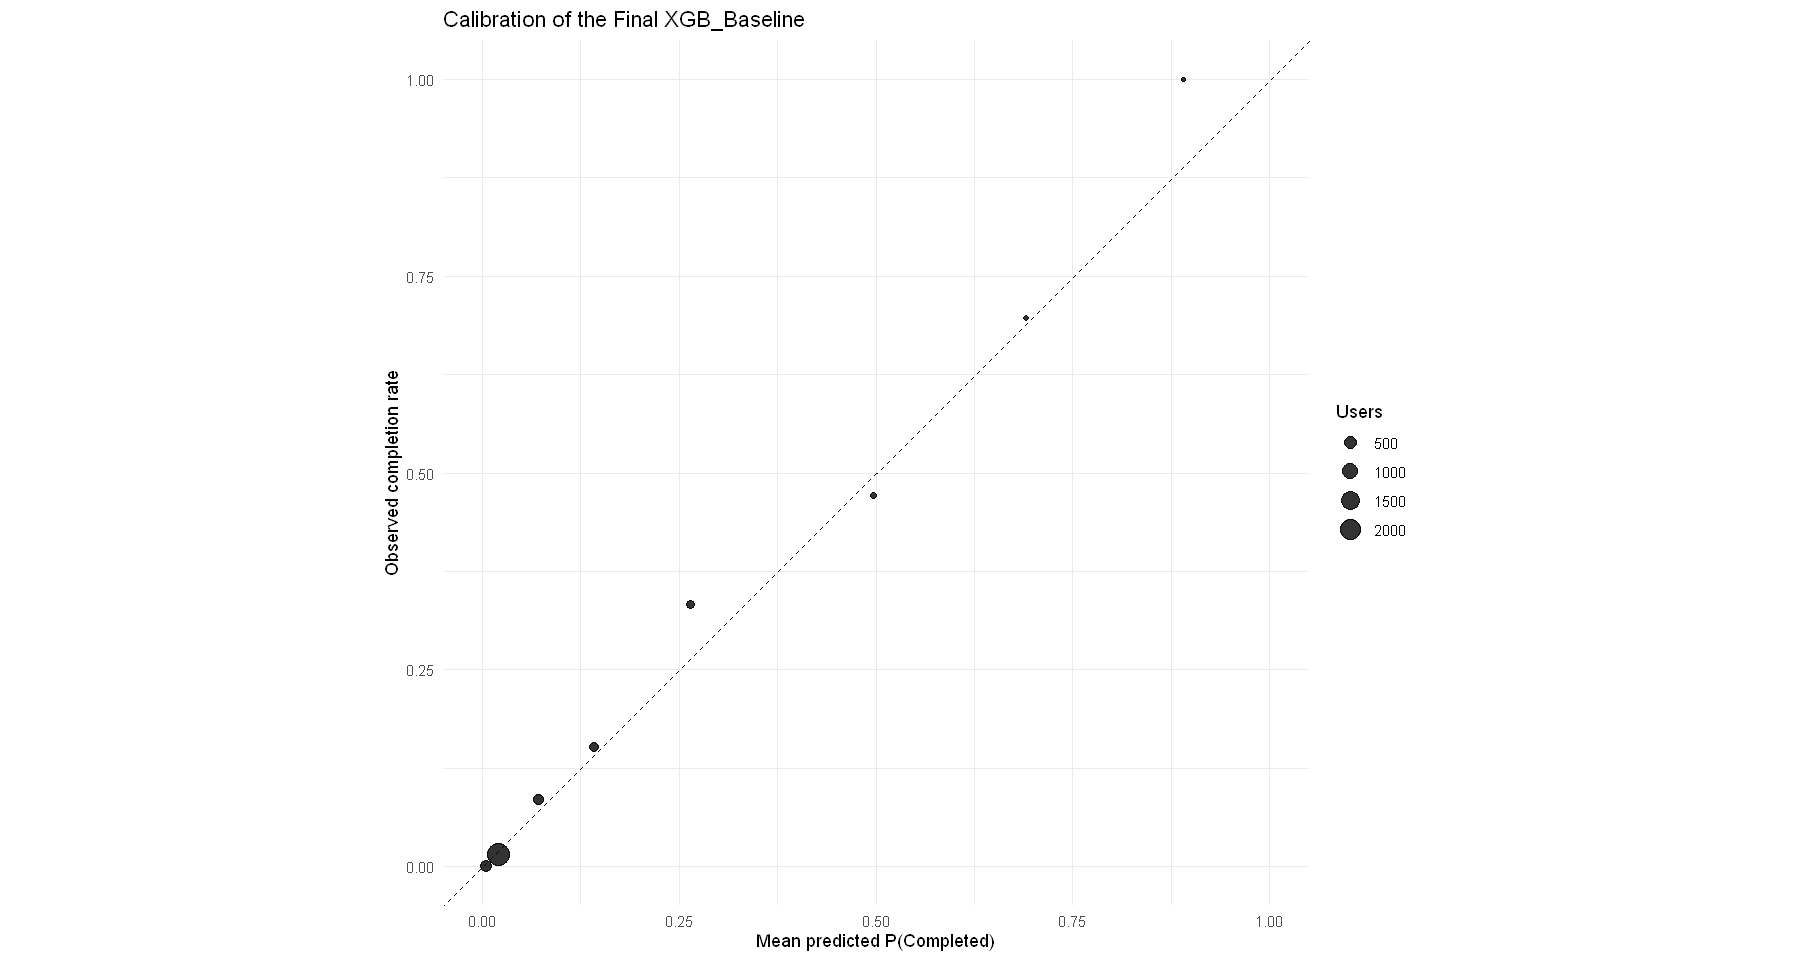

In [95]:
# Visualize calibration of the selected final model.
ggplot(
  xgb_calibration_test,
  aes(
    x = Mean_P_Completed,
    y = Actual_Completion_Rate
  )
) +
  geom_abline(
    intercept = 0,
    slope = 1,
    linetype = "dashed"
  ) +
  geom_point(
    aes(size = Users),
    alpha = 0.8
  ) +
  coord_equal(
    xlim = c(0, 1),
    ylim = c(0, 1)
  ) +
  scale_size_continuous(
    name = "Users"
  ) +
  labs(
    title = "Calibration of the Final XGB_Baseline",
    x = "Mean predicted P(Completed)",
    y = "Observed completion rate"
  ) +
  theme_minimal()

**Visual Interpretation: Calibration Plot**

The dashed diagonal represents perfect calibration, where the mean predicted `P(Completed)` equals the observed completion rate. Points below the diagonal indicate overestimation of completion probability, while points above it indicate underestimation.

`XGB_Baseline` follows the reference line reasonably closely across most probability ranges. The larger deviations occur mainly in bins containing fewer learners, particularly at the highest predicted probabilities, so these estimates are less stable and should be interpreted cautiously.

Point size represents the number of learners in each probability bin. Most observations are concentrated in the low-probability region, reflecting the low overall completion rate in the analytical sample.

Overall, the plot does not indicate a strong systematic calibration bias, although calibration should be reassessed on future cohorts before the predictions are interpreted as precise individual probabilities.

### Calibration Summary: Brier Score

In [96]:
# Summarize overall probabilistic accuracy using the Brier Score.
calibration_summary_test <- get_brier_score(
      model_id = final_ranking_model_id,
      probs_completed = xgb_final_probs_test,
      truth = test_data_engineered$completion_status,
      positive_class = positive_class
)
calibration_summary_test

Model_ID,Brier_Score,Mean_P_Completed,Actual_Completion_Rate
<chr>,<dbl>,<dbl>,<dbl>
XGB_Baseline,0.0406,0.0634,0.0641


**Calibration Interpretation: Brier Score**

The Brier Score of **0.0406** summarizes the overall squared error of the predicted completion probabilities.

The mean predicted completion probability (**0.0634**) is closely aligned with the observed completion rate (**0.0641**) at the population level. However, this aggregate agreement does not imply perfect calibration within every probability range.

Together with the probability-bin analysis, the result suggests that the model produces useful approximate probability scores. Calibration should nevertheless be reassessed on future cohorts before individual predictions are interpreted as precise completion probabilities.

---

## XGBoost Feature Importance

> **Technical Note**
>
> This section examines the feature-importance profile of the selected progress-aware `XGB_Baseline`.
>
> Importance is reported using XGBoost **Gain** and reflects relative predictive contribution rather than causal influence. Because several features describe related aspects of learner progress and engagement, importance may be distributed across correlated predictors.

In [97]:
# Extract XGBoost feature importance for the selected ranking model.
# Gain is used as the main importance measure because it reflects
# each feature's contribution to improving tree split quality.
xgb_importance <- xgboost::xgb.importance(
  feature_names = features_engineered,
  model = final_ranking_model
)

# Convert importance output to data.table for easier inspection and reporting.
xgb_importance_dt <- as.data.table(xgb_importance)

In [98]:
# Keep the top 10 most important features for compact interpretation.
xgb_importance_top <- xgb_importance_dt[1:10]

xgb_importance_top

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
n_passed_practical,0.63685011,0.25428643,0.13907285
n_passed_all,0.11572851,0.09090411,0.07947020
practical_pass_rate,0.05031214,0.09261104,0.07682119
days_since_last_action,0.03921179,0.07774942,0.09668874
submission_correct_rate,0.03251101,0.07247616,0.06225166
n_viewed_all,0.02982566,0.09990589,0.10463576
active_days,0.01576716,0.04344702,0.03973510
n_submissions,0.01292824,0.03443546,0.04105960
started_practical_per_viewed_step,0.01264097,0.02641474,0.05298013


**Interpretation: XGBoost Feature Importance**

The feature-importance profile is strongly concentrated around early practical progress. `n_passed_practical` accounts for approximately **63.7%** of total Gain, making it the dominant predictor, followed by `n_passed_all` with approximately **11.6%**.

The remaining importance is distributed across complementary signals, including practical performance, learning recency, course engagement, submission quality, and activity consistency.

Overall, the model relies primarily on evidence of successful early progress, while additional behavioral features refine the predicted completion ranking. These importance values describe predictive contribution and should not be interpreted as causal effects.

## Dominant Progress-Feature Family Ablation

> **Technical Note: Dominant Practical-Pass Feature-Family Ablation**
>
> `n_passed_practical` is the dominant feature in the selected progress-aware `XGB_Baseline`.
>
> This analysis removes `n_passed_practical` together with its direct derivatives, `has_passed_practical` and `practical_pass_rate`, and retrains the model using the same baseline configuration.
>
> The goal is to assess whether predictive performance depends mainly on this feature family or remains supported by a broader combination of progress, engagement, productivity, and recency signals.
>
> This is a robustness diagnostic and does not participate in model selection.

In [99]:
# Remove the dominant practical-pass feature family:
# the raw feature and its two direct derivatives.
dominant_feature_family <- c(
  "n_passed_practical",
  "has_passed_practical",
  "practical_pass_rate"
)

features_without_dominant <- setdiff(
  features_engineered,
  dominant_feature_family
)

In [100]:
# Validate that the complete practical-pass feature family was removed
# and that all remaining features exist.
stopifnot(
  !any(dominant_feature_family %in% features_without_dominant),
  all(features_without_dominant %in% names(train_data_engineered)),
  all(features_without_dominant %in% names(val_data_engineered))
)

In [101]:
# XGBoost ablation using the same baseline XGB_Baseline setup,
# but without the practical-pass feature family.
dtrain_no_dominant <- make_xgb_dmatrix_generic(
  train_data_engineered,
  features_without_dominant
)

dval_no_dominant <- make_xgb_dmatrix_generic(
  val_data_engineered,
  features_without_dominant
)

xgb_no_dominant_params <- list(
  objective = "binary:logistic",
  eval_metric = "aucpr",
  eta = 0.05,
  max_depth = 4,
  min_child_weight = 1,
  subsample = 0.8,
  colsample_bytree = 0.8,
  nthread = 1
)

In [102]:
# Refit XGBoost with the same parameters, but without the
# practical-pass feature family.
# This assesses how much validation performance depends on this
# closely related group of progress-aware predictors.
set.seed(42)

xgb_no_dominant <- xgboost::xgb.train(
  params = xgb_no_dominant_params,
  data = dtrain_no_dominant,
  nrounds = 500,
  evals = list(train = dtrain_no_dominant, val = dval_no_dominant),
  callbacks = list(
    xgboost::xgb.cb.early.stop(
      stopping_rounds = 30,
      maximize = TRUE,
      metric_name = "val_aucpr",
      verbose = FALSE,
      save_best = TRUE
    )
  ),
  verbose = 0
)

In [103]:
# Predict validation probabilities using the reduced feature set.
xgb_no_dominant_probs_val <- predict(xgb_no_dominant, dval_no_dominant)

In [104]:
# Evaluate the reduced-feature XGBoost model on validation data.
xgb_no_dominant_val_result <- evaluate_validation_model(
  probs_val = xgb_no_dominant_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)


In [105]:
# Label the result for ablation comparison tables.
xgb_no_dominant_val_result[, `:=`(
  Feature_Set = "Progress_Aware_No_Practical_Pass_Family",
  Model_ID = "XGB_Baseline"
)]

### Dominant Feature Ablation Comparison

In [106]:
# Combine full and ablated validation results.
dominant_feature_ablation_comparison <- rbindlist(
  list(
    xgb_baseline_val_result,
    xgb_no_dominant_val_result
  ),
  use.names = TRUE,
  fill = TRUE
)

In [107]:
# Create a compact reporting table focused on the main validation metrics.
dominant_feature_ablation_comparison_compact <- dominant_feature_ablation_comparison[
  ,
  .(
    Feature_Set,
    Model_ID,
    Threshold = Val_Threshold,
    ROC_AUC = Val_ROC_AUC,
    PR_AUC = Val_PR_AUC,
    Recall = Val_Recall,
    Precision = Val_Precision,
    F2 = Val_F2,
    FPR = Val_FPR
  )
]

dominant_feature_ablation_comparison_compact

Feature_Set,Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware_Engineered,XGB_Baseline,0.13,0.9084865,0.605705,0.6995708,0.4044665,0.6104869,0.07058824
Progress_Aware_No_Practical_Pass_Family,XGB_Baseline,0.12,0.9050549,0.586421,0.7167382,0.3874710,0.6126192,0.07764706


**Practical-Pass Feature-Family Ablation Summary**

Removing the practical-pass feature family—`n_passed_practical`, `has_passed_practical`, and `practical_pass_rate`—produces a modest reduction in ranking performance. ROC-AUC decreases from **0.9085** to **0.9051**, while PR-AUC falls from **0.6057** to **0.5864**.

At the validation-selected threshold, Recall increases from **0.700** to **0.717**, and F2 changes only slightly from **0.610** to **0.613**. However, this is accompanied by lower Precision (**0.404 → 0.387**) and a higher FPR (**0.071 → 0.078**).

These results indicate that the removed feature family contributes meaningfully to probability ranking, but the model does not depend on it exclusively. Other progress, engagement, productivity, submission, and recency variables retain most of the predictive signal and compensate partly for its removal.

The following feature-importance analysis examines which remaining predictors become most influential in the ablated model.

---

## Feature Importance After Removing the Practical-Pass Feature Family

In [108]:
# Extract the top feature importances after removing
# the practical-pass feature family.
xgb_no_dominant_importance_top <- head(
  as.data.table(
    xgboost::xgb.importance(
      feature_names = features_without_dominant,
      model = xgb_no_dominant
    )
  )[
    order(-Gain),
    .(Feature, Gain)
  ],
  10L
)

xgb_no_dominant_importance_top

Feature,Gain
<chr>,<dbl>
n_passed_all,0.55364200
score_per_active_day,0.07646130
days_since_last_action,0.07052780
submission_correct_rate,0.06369734
n_started_practical,0.05660233
n_submissions,0.04025661
n_viewed_all,0.03553115
submissions_per_started_practical,0.03143932
active_days,0.02379162


**Ablation Feature Importance Summary**

After removing the practical-pass feature family—`n_passed_practical`, `has_passed_practical`, and `practical_pass_rate`—importance shifts strongly toward the broader progress measure `n_passed_all`, which accounts for approximately **55.4%** of total Gain.

The remaining importance is distributed across learning productivity, recency, submission quality, practical activation, overall engagement, and submission intensity. `score_per_active_day`, `days_since_last_action`, and `submission_correct_rate` are the next most influential features, but each contributes substantially less than `n_passed_all`.

Overall, the model does not depend exclusively on the practical-pass feature family. However, its predictions remain strongly progress-aware because `n_passed_all` and other progress-related variables can partially compensate for the removed features.

---

## Leakage-Reduced Feature Set Robustness Check

> **Technical Note: Leakage-Reduced Robustness Check**
>
> The final progress-aware `XGB_Baseline` includes features that may partially reflect information closely related to the completion target.
>
> This robustness check retrains the same XGBoost configuration using a leakage-reduced feature set that excludes direct progress and score-related predictors while retaining engagement, activity, recency, and practical-start signals.
>
> The same data split and validation-based threshold-selection procedure are used. This analysis evaluates how much predictive information remains in early behavioral signals alone and does not participate in final model selection.

In [109]:
# Practical-start variables are retained because they represent activation and engagement behavior rather than successful completion, score accumulation, or passed-step progress. 
# In contrast, passed, score, submission-related, and productivity variables are removed as direct progress proxies.
engagement_only_features <- c(
  "n_viewed_all",
  "n_started_practical",
  "active_days",
  "days_since_last_action",
  "has_started_practical",
  "is_recently_active",
  "started_practical_per_viewed_step",
  "practical_starts_per_active_day"
)

# Features that should not be included in the leakage-reduced feature set
# because they directly reflect score, pass, submission activity, or progress.
progress_proxy_features <- c(
  "n_passed_all",
  "n_passed_practical",
  "n_submissions",
  "submission_correct_rate",
  "score_per_active_day",
  "steps_per_active_day",
  "has_submitted",
  "has_passed_practical",
  "practical_pass_rate",
  "submissions_per_started_practical",
  "passed_per_viewed_step",
  "submissions_per_active_day"
)

stopifnot(all(engagement_only_features %in% names(train_data_engineered)))
stopifnot(!any(progress_proxy_features %in% engagement_only_features))

---

### Engagement-Only XGBoost Validation Check

In [110]:
# Prepare XGBoost matrices for the engagement-only feature set.
# The test matrix is created here as well so the same feature structure
# can be reused later during final holdout evaluation if needed.
dtrain_clean <- make_xgb_dmatrix_generic(
  train_data_engineered,
  engagement_only_features
)

dval_clean <- make_xgb_dmatrix_generic(
  val_data_engineered,
  engagement_only_features
)

dtest_clean <- make_xgb_dmatrix_generic(
  test_data_engineered,
  engagement_only_features
)

In [111]:
# Define a baseline XGBoost configuration for the engagement-only robustness check.
xgb_clean_params <- list(
  objective = "binary:logistic",
  eval_metric = "aucpr",
  eta = 0.05,
  max_depth = 4,
  min_child_weight = 1,
  subsample = 0.8,
  colsample_bytree = 0.8,
  nthread = 1
)

In [112]:
# Train the engagement-only XGBoost model with validation monitoring.
# This checks how much predictive signal remains after removing
# direct progress- and score-based proxy features.
set.seed(42)
xgb_clean <- xgboost::xgb.train(
  params = xgb_clean_params,
  data = dtrain_clean,
  nrounds = 500,
  evals = list(train = dtrain_clean, val = dval_clean),
  early_stopping_rounds = 30,
  maximize = TRUE,
  verbose = 0
)

# Predict validation probabilities for the positive class.
xgb_clean_probs_val <- predict(xgb_clean, dval_clean)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_clean_probs_val >= 0 & xgb_clean_probs_val <= 1))

In [113]:
# Evaluate the engagement-only XGBoost model on validation data.
xgb_clean_val_result <- evaluate_validation_model(
  probs_val = xgb_clean_probs_val,
  val_truth = val_data_engineered$completion_status,
  optimize_metric = "F2",
  positive_class = positive_class
)

# Label the result for robustness-check comparison tables.
xgb_clean_val_result[, `:=`(
  Feature_Set = "Engagement_Only",
  Model_ID = "XGB_Baseline"
)]
 

In [114]:
# Combine validation results for the progress-aware
# and engagement-only XGBoost models.
engagement_validation_comparison <- rbindlist(
  list(
    copy(xgb_baseline_val_result)[
      ,
      Feature_Set := "Progress_Aware"
    ],
    copy(xgb_clean_val_result)
  ),
  use.names = TRUE,
  fill = TRUE
)

# Keep only the main validation metrics
# for a compact feature-set comparison.
engagement_validation_comparison_compact <-
  engagement_validation_comparison[
    ,
    .(
      Feature_Set,
      Model_ID,
      Threshold = Val_Threshold,
      ROC_AUC = Val_ROC_AUC,
      PR_AUC = Val_PR_AUC,
      Recall = Val_Recall,
      Precision = Val_Precision,
      F2 = Val_F2,
      FPR = Val_FPR
    )
  ]

# Display the compact validation comparison.
engagement_validation_comparison_compact

Feature_Set,Model_ID,Threshold,ROC_AUC,PR_AUC,Recall,Precision,F2,FPR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Progress_Aware,XGB_Baseline,0.13,0.9084865,0.6057050,0.6995708,0.4044665,0.6104869,0.07058824
Engagement_Only,XGB_Baseline,0.08,0.8947469,0.5263931,0.7467811,0.3026087,0.5773059,0.11794118


**Result Summary: Engagement-Only Validation Robustness Check**

Using the leakage-reduced engagement-only feature set reduces validation performance relative to the progress-aware `XGB_Baseline`. PR-AUC falls to **0.5264**, while F2 decreases to **0.577**.

Despite this reduction, the model retains meaningful predictive performance. Recall remains relatively high at **0.747**, although this is accompanied by lower Precision (**0.303**) and a higher FPR (**0.118**).

These results indicate that engagement, activity, recency, and practical-start variables retain predictive information after explicit progress and score-related features are removed. However, progress-related features contribute substantially to the stronger performance of the final model.

This validation analysis is a robustness diagnostic and does not affect final model selection.

---

## Engagement-Only Final Holdout Robustness Check

> **Technical Note: Engagement-Only Holdout Robustness Check**
>
> This section evaluates the engagement-only `XGB_Baseline` on the reserved test set using the threshold selected during validation.
>
> No additional tuning or threshold adjustment is performed on the test set. The purpose is to assess whether engagement, recency, and practical-start signals retain predictive value on unseen learners after explicit progress- and score-related features are removed.
>
> This is a post-selection robustness diagnostic and does not affect the final model choice.

In [115]:
# Predict final holdout probabilities for the engagement-only XGBoost model.
xgb_clean_probs_test <- predict(xgb_clean, dtest_clean)

# Sanity check: predicted probabilities must stay within valid probability bounds.
stopifnot(all(xgb_clean_probs_test >= 0 & xgb_clean_probs_test <= 1))

In [116]:
# Evaluate engagement-only XGBoost on the reserved test set
# using the threshold selected on validation data.
xgb_clean_test_result <- evaluate_final_test_model(
  probs_test = xgb_clean_probs_test,
  test_truth = test_data_engineered$completion_status,
  threshold = xgb_clean_val_result$Val_Threshold,
  positive_class = positive_class
)

In [117]:
# Prepare progress-aware and engagement-only holdout results
# for a compact robustness comparison.
holdout_robustness_comparison <- rbindlist(
  list(
    copy(xgb_final_test_result)[
      ,
      `:=`(
        Feature_Set = "Progress_Aware",
        Model_ID = final_ranking_model_id
      )
    ],
    copy(xgb_clean_test_result)[
      ,
      `:=`(
        Feature_Set = "Engagement_Only",
        Model_ID = final_ranking_model_id
      )
    ]
  ),
  use.names = TRUE,
  fill = TRUE
)

holdout_robustness_comparison

Threshold,Test_ROC_AUC,Test_PR_AUC,Test_Recall,Test_Precision,Test_F1,Test_F2,Test_Specificity,Test_FPR,Test_FNR,Feature_Set,Model_ID
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0.13,0.9042,0.5524,0.704,0.390,0.502,0.607,0.925,0.075,0.296,Progress_Aware,XGB_Baseline
0.08,0.8875,0.4878,0.751,0.301,0.430,0.578,0.881,0.119,0.249,Engagement_Only,XGB_Baseline


**Result Summary: Engagement-Only Holdout Robustness Check**

The holdout results confirm that the progress-aware feature set provides stronger overall predictive performance. Compared with the engagement-only model, it achieves higher ROC-AUC (**0.9042 vs. 0.8875**), PR-AUC (**0.5524 vs. 0.4878**), Precision (**0.390 vs. 0.301**), and F2 (**0.607 vs. 0.578**).

The engagement-only model identifies a larger share of completed learners, with Recall increasing from **0.704** to **0.751**. However, this is achieved at the cost of a substantially higher FPR (**0.119 vs. 0.075**) and lower precision.

Overall, engagement, recency, and practical-start variables retain predictive information on unseen learners, but explicit progress-related features contribute materially to stronger ranking and classification performance. The progress-aware `XGB_Baseline` therefore remains the final operational model.

This comparison is a post-selection robustness diagnostic and does not alter the final model or its validation-derived threshold.

---

## Reproducibility: Model and Results Registry

> **Technical Note: Model and Results Registry**
>
> This section provides a consolidated registry of the principal trained models and result tables generated throughout the analytical workflow. Its purpose is to support reproducibility, transparency, and convenient inspection of the final modeling artifacts.
>
> The registry is intended for documentation only and does not play any role in model selection or evaluation. Model selection was completed using the validation set, and final performance was subsequently confirmed on the reserved holdout test set.

In [118]:
# Collect all evaluation, tuning, robustness,
# calibration, policy, and importance tables
# in one named list for convenient inspection or export.
all_result_tables <- list(
  validation_results_original = baseline_results_validation,
  validation_results_engineered = engineered_results_validation,

  tuning_results_xgb = xgb_tuning_results,
  tuning_best_xgb = best_xgb_params_compact,
  tuning_comparison_validation = xgb_tuning_comparison_val,

  final_test_result = xgb_final_test_result,

  policy_results_high_risk = xgb_policy_test,
  policy_results_high_completion = xgb_completion_priority_test,

  calibration_bins_test = xgb_calibration_test,
  calibration_summary_test = calibration_summary_test,

  importance_progress_aware = xgb_importance_dt,

  ablation_results = dominant_feature_ablation_comparison,
  ablation_importance_top = xgb_no_dominant_importance_top,

  robustness_results_validation = engagement_validation_comparison,
  robustness_results_test = holdout_robustness_comparison
)


In [ ]:
# Collect all trained model objects in one named list
# for reuse, inspection, or serialization.
all_model_objects <- list(
  baseline_models_original = models_original,
  baseline_models_engineered = models_engineered,

  tuned_xgb_candidate = xgb_baseline_tuned,
  final_xgb_model = final_ranking_model,

  ablation_xgb_no_practical_pass_family = xgb_no_dominant,
  robustness_xgb_engagement_only = xgb_clean
)

In [119]:
# Export Model Objects and Result Tables
model_output_dir <- file.path(project_root, "models")
results_output_dir <- file.path(project_root, "results")

dir.create(model_output_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(results_output_dir, showWarnings = FALSE, recursive = TRUE)

In [120]:
# Save all model objects as one RDS file
saveRDS(
  all_model_objects,
  file = file.path(model_output_dir, "completion_risk_model_objects.rds")
)

# Save all result tables as one RDS file
saveRDS(
  all_result_tables,
  file = file.path(results_output_dir, "completion_risk_result_tables.rds")
)

## Business Risk Scoring and Retention Strategy

The final model output is translated into an operational retention score:

`Risk_Not_Completed = 1 - P(Completed)`

`XGB_Baseline` is trained to predict the rare `Completed` class. For retention prioritization, the probability is inverted so that learners with the lowest predicted completion probability receive the highest risk score.

The score should be interpreted primarily as a **progress-aware ranking signal**, rather than as a hard binary prediction or an exact individual probability. It combines first-10-day behavioral and progress-related information to prioritize learners showing weaker early completion trajectories.

**Intervention Capacity Scenarios**

| Priority group | Suggested capacity | Typical early profile | Recommended intervention |
|---|---:|---|---|
| Critical priority | Highest-risk 5% | Very weak early progress, little practical activation, possible early inactivity | Immediate nudge, first-task prompt, simplified entry path |
| High priority | Highest-risk 10% | Weak progress accumulation and limited practical engagement | Onboarding support, first-submission guidance, skeleton code |
| Medium-high priority | Highest-risk 20% | Some activity, but unstable progress or engagement | Progress feedback, next-step recommendation, task hints |
| Broad priority pool | Highest-risk 30% | Elevated risk and weaker early completion trajectory | Low-cost automated campaign or reactivation reminder |
| Lower priority | Remaining learners | Stronger predicted completion probability or more stable engagement | Minimal retention intervention; optional achievement-oriented messaging |



**Operational Model**

`XGB_Baseline` is retained as the single operational model because the tuned candidate provides only a marginal improvement in PR-AUC, while XGB_Baseline offers a slightly more favorable F2–FPR trade-off. Holdout calibration diagnostics show reasonable alignment between its predicted and observed completion rates.

**Robustness Qualification**

The practical-pass feature-family ablation shows that removing `n_passed_practical` together with `has_passed_practical` and `practical_pass_rate` produces only a modest decline in ranking performance. Although practical progress remains the strongest source of predictive signal, the model also uses broader progress, engagement, productivity, submission, and recency variables.

The leakage-reduced engagement-only analysis retains meaningful predictive performance after explicit progress- and score-related variables are removed. However, its weaker PR-AUC, Precision, F2, and higher FPR confirm that progress-related features contribute materially to the stronger performance of the final model.

Overall, `XGB_Baseline` provides a practical framework for early retention prioritization. Its output can be used to allocate limited intervention resources, but the analysis demonstrates prioritization quality rather than the causal effectiveness of any proposed intervention.

## Final Project Conclusion

**1. Early behavior contains a strong completion signal**

The project demonstrates that learner behavior during the first **10 days** contains substantial predictive information about eventual course completion. Engagement, practical activation, progress, productivity, and recency help distinguish learners with stronger completion trajectories from those at higher risk of non-completion.

**2. The final model is progress-aware rather than fully leakage-free**

Because course completion is defined by achieving the required course score, `XGB_Baseline` should be interpreted as a **progress-aware completion prediction model**. Several of its strongest predictors describe early practical progress, passed steps, submissions, and related outcomes that are closely associated with the completion criterion.

The model therefore supports **early progress monitoring** rather than fully leakage-free future prediction. It identifies learners who already exhibit stronger or weaker completion trajectories during the first 10 days.

**3. Feature engineering strengthened the prediction pipeline**

Feature engineering improved the representation of learner behavior through activation, behavioral-intensity, productivity, progress-ratio, and recency features.

Targeted XGBoost tuning produced only a negligible improvement in validation PR-AUC and a less favorable threshold-based trade-off. Therefore, the original engineered `XGB_Baseline` configuration was retained as the final model.

**4. Robustness analyses qualify the main findings**

In the validation-set ablation, removing the dominant practical-pass feature family produces a modest reduction in ranking performance, while threshold-based performance remains broadly stable. This indicates that the model does not depend exclusively on n_passed_practical and its direct derivatives.

Within the ablated validation model, much of the feature importance shifts toward n_passed_all and other progress-related variables. The model therefore remains strongly progress-aware, even after the dominant practical-pass features are removed.

The leakage-reduced engagement-only model also retains meaningful predictive performance after explicit progress- and score-related predictors are excluded. Its weaker PR-AUC, Precision, F2, and higher FPR nevertheless confirm that progress-related features contribute materially to the stronger performance of the final model.

**5. Final operational model**

`XGB_Baseline` is retained as the single final operational model. It estimates `P(Completed)` and supports continuous probability-based ranking.

For retention prioritization, the completion probability is converted into:

`Risk_Not_Completed = 1 - P(Completed)`

Learners with the lowest predicted completion probabilities are assigned the highest intervention priority. The validation-derived classification threshold is retained as a diagnostic for detecting the `Completed` class, while operational targeting is based primarily on the continuous risk ranking and available intervention capacity.

**6. Business implications**

The framework enables a shift from retrospective completion analysis to proactive learner retention. Learners can be evaluated during the first **10 days** and prioritized for intervention before disengagement becomes more difficult to reverse.

The output should primarily be interpreted as a **progress-aware risk-ranking score**, not as an exact individual probability or evidence that an intervention will improve completion. The effectiveness of specific retention actions should be evaluated separately through controlled experiments such as A/B testing.

## Production Limitations and Deployment Considerations

Several limitations should be considered before using the proposed model in a production retention workflow.

**1. Progress-aware target-proxy risk**

Course completion is defined by reaching at least **75 points**. Consequently, several predictors—including passed steps, submissions, practical success, and early progress measures—are closely related to the target definition.

During dataset preparation, **126 learners (0.69%)** had already reached the completion threshold within the first **10-day** observation window. The final `XGB_Baseline` should therefore be interpreted as a **progress-aware risk-ranking model**, rather than as a fully leakage-free future prediction model.

The validation-set practical-pass feature-family ablation shows that removing `n_passed_practical` together with `has_passed_practical` and `practical_pass_rate` produces only a modest decline in ranking performance. Although practical progress remains the strongest source of predictive signal, the model also uses broader progress, engagement, productivity, submission, and recency variables.

**2. Leakage-reduced robustness**

The engagement-only robustness check removes explicit progress- and score-related predictors.

The reduced model retains meaningful predictive performance, indicating that engagement, activity, recency, and practical-start behavior contain predictive information even without direct progress measures. However, its weaker PR-AUC, Precision, F2, and higher FPR show that progress-related variables contribute materially to the stronger performance of the final model.

The engagement-only feature set should be considered **leakage-reduced**, not fully leakage-free, because some behavioral variables may still indirectly reflect course progress.

**3. Probability interpretation**

`XGB_Baseline` provides reasonably aligned probability estimates at the population level, but calibration is not perfect across all probability ranges. Estimates in sparsely populated high-probability bins are particularly uncertain.

The model output should therefore be used primarily as a **risk-ranking signal**:

`Risk_Not_Completed = 1 - P(Completed)`

It should not be interpreted as an exact individual probability without further validation and calibration on future cohorts.

**4. Validation-set reuse and statistical uncertainty**

The validation set was used for feature-set comparison, model comparison, targeted tuning, threshold selection, and final model selection. Validation metrics should therefore be interpreted as model-development diagnostics.

The reserved holdout test set provides the main estimate of generalization performance. However, the analysis is still based on a single train/validation/test split and does not include confidence intervals or repeated cross-validation. Small metric differences should therefore not be interpreted as definitive statistical superiority.

**5. Cohort and outcome-definition limitations**

The analytical sample is based on learners whose final status could be resolved under the adopted completion and inactivity rules. This may introduce selection bias if unresolved or censored learners differ systematically from the included population.

The non-completion outcome also depends partly on the selected inactivity definition. Learners classified after a **14-day inactivity period** may later return to the course, meaning that some labels may contain outcome uncertainty.

**6. Random rather than temporal validation**

The current split evaluates generalization to unseen learners from the same historical data distribution.

A random split does not fully test performance under future changes in learner behavior, course design, or platform conditions. Before deployment, the model should also be evaluated using a temporal holdout in which later cohorts are predicted from earlier cohorts.

**7. Population and preprocessing scope**

The model was developed after applying the selected analytical population and preprocessing rules, including restrictions used to control extreme behavior.

Performance may differ for learners outside this population, including highly active outliers or users with unusual learning patterns. Production scoring should therefore use the same feature definitions and population rules unless the model is revalidated.

**8. Historical-course dependency**

The model was developed using historical data from a specific course setting. Changes in scoring rules, practical assignments, course structure, platform design, or learner population may affect performance.

This is especially relevant for the progress-aware predictors, whose meaning depends on the design of the course and its assessment structure.

**9. Observation-window limitation**

The current workflow uses only the first **10 days** of learner activity.

Future work should compare alternative observation windows, such as **3, 7, and 14 days**, to evaluate the trade-off between earlier intervention and predictive reliability.

A stricter future-prediction setup should also exclude learners who have already completed the course by the prediction timestamp.

**10. No causal intervention estimate**

The model identifies learners with weaker observed completion trajectories, but it does not estimate whether a specific intervention will improve their outcome.

The effectiveness of reminders, onboarding support, task guidance, skeleton code, or other retention actions must be evaluated separately through controlled experiments such as randomized A/B tests.

**11. Production monitoring requirements**

A production implementation should continuously monitor:

- data and concept drift;
- probability calibration;
- ranking and threshold-based performance;
- performance across learner segments;
- changes in course structure and scoring logic;
- intervention capacity and threshold suitability;
- the need for recalibration or model retraining.

Overall, `XGB_Baseline` should be regarded as a **decision-support model for prioritizing retention interventions**, not as a causal explanation of learner completion or a perfectly calibrated individual risk estimate.